# Trajectory aggregation, step by step

This notebook re-does what `d4rt_agent/sam_orientany_d4rt_test` does *after* the models have
run — no SAM3, no Orient-Anything, no D4RT forward pass. Everything below reads the arrays this
run already wrote to disk and rebuilds the analysis by hand, plotting the state after every step.

The pipeline that produced the inputs:

```
text phrase ──SAM3──▶ per-frame masks ──┬──▶ 20 seed points ──D4RT──▶ 3D tracks (P=20, T=32)
                                        └──▶ 12×12 image grid ──D4RT──▶ camera-recovery cloud
```

What this notebook rebuilds (mirrors `traj3d_analyze.py` + `traj3d_geometry.py`):

| Step | What happens | Where it lives in the pipeline |
|---|---|---|
| 1 | logits → probabilities, gate on visibility/confidence | `sigmoid`, `build_trajectory` |
| 2 | look at the 20 raw 3D tracks | — |
| 3 | **RANSAC** over Kabsch → per-frame camera pose | `robust_rigid`, `recover_camera_poses` |
| 4 | reject whole bad tracks (3 tests) | `select_tracks` |
| 5 | **median** — weighted geometric median per frame | `geometric_median`, `aggregate_trajectory` |
| 6 | Savitzky–Golay smoothing | `smooth_trajectory` |
| 7 | **post-processing** — running mean, then drop axes that only carry noise | *(not in the pipeline)* |
| 8 | check the rebuild against the pipeline's own output | — |
| 9 | **camera-to-subject separation** over time | *(not in the pipeline)* |

One clip at a time: pick it with `VIDEO` in the setup cell and *Run All*.

Panels that belong to one group — the X, Y and Z of the same quantity — are drawn on a **single
locked scale** via `lock_axes`, never autoscaled individually. Independently scaled panels make an
axis carrying 0.1 units look exactly as busy as one carrying 1.7, which is the fastest way to
misread this data. Where a panel sits outside the group (a step length, an inlier count) it keeps
its own scale, and rows for the subject and the camera are locked separately because their
magnitudes differ by roughly a hundredfold.

Two different things are called "RANSAC" here, and they are worth keeping apart:

* **Step 3** is real RANSAC — random 3-point minimal samples, consensus scoring — used to fit the
  camera's rigid motion from the 144-point grid.
* **Step 5**'s output column is *named* `ransac_median`, but it is not RANSAC. The outlier
  rejection happened once, at track level, in step 4; step 5 is the weighted geometric median of
  whatever survived. The name is historical.

## Setup — pick the clip here

Pure NumPy + Matplotlib; nothing below needs a GPU or a model checkpoint.

**`VIDEO` in the next cell is the only knob.** Set it, *Run All*, and every step from here to the
end runs on that one clip. Running the cell prints the clips found in this run directory, so on a
first pass just run it, read the list, change the number and run again.

In [191]:
import json, warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
from PIL import Image

warnings.filterwarnings("ignore", category=RuntimeWarning)   # nanmedian over all-NaN slices
np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.dpi": 110, "figure.facecolor": "white",
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 9})

# Axis directions, spelled out on every plot so the sign of a number is never in doubt.
# D4RT uses the OpenCV camera frame (src/data/co3d_raw_dataset.py:74).
AX = ["X (+ve right)", "Y (+ve down)", "Z (+ve forward)"]


def label_3d(ax):
    """Put the signed axis names on a 3D plot."""
    ax.set_xlabel(AX[0]); ax.set_ylabel(AX[1]); ax.set_zlabel(AX[2])


def lock_axes(axes, x=True, y=True, pad=0.05):
    """Give a group of panels ONE common scale.

    Panels that each autoscale are easy to misread: an axis carrying 0.1 units of motion and one
    carrying 1.7 are drawn the same height, so they look equally important.  Locking the group to
    a shared range makes the comparison honest -- a small axis is *drawn* small.
    """
    axes = list(np.ravel(axes))
    if y:
        lo = min(a.get_ylim()[0] for a in axes); hi = max(a.get_ylim()[1] for a in axes)
        m = pad * max(hi - lo, 1e-9)
        for a in axes: a.set_ylim(lo - m, hi + m)
    if x:
        lo = min(a.get_xlim()[0] for a in axes); hi = max(a.get_xlim()[1] for a in axes)
        for a in axes: a.set_xlim(lo, hi)
    return axes


# Locate the run.  This notebook lives next to the pipeline it explains, not inside a run
# directory, so the path is resolved rather than hard-coded: set RUN_DIR to override.
RUN_NAME = "traj3d_a100_20260819T100744Z"        # the run these saved outputs came from
RUN_DIR  = None

if RUN_DIR is None:
    here = Path.cwd()
    if (here / "run_metadata.json").exists():                     # started inside a run dir
        RUN_DIR = here
    else:
        root = next((q for q in [here, *here.parents]
                     if (q / "d4rt_agent" / "results").is_dir()), None)
        results = (root / "d4rt_agent" / "results") if root else None
        if results is not None and (results / RUN_NAME).is_dir():
            RUN_DIR = results / RUN_NAME
        elif results is not None and sorted(results.glob("traj3d_*")):
            RUN_DIR = sorted(results.glob("traj3d_*"))[-1]         # fall back to the newest run
        else:
            raise SystemExit("no run directory found -- set RUN_DIR above by hand")
RUN_DIR = Path(RUN_DIR)
print(f"run: {RUN_DIR}")

VIDEOS = sorted(p.name for p in RUN_DIR.iterdir() if p.is_dir())

# ===========================================================================
#  SELECT THE CLIP  --  every step in this notebook runs on this one
# ===========================================================================
VIDEO = 2
# ===========================================================================

VIDEO = int(VIDEO) % len(VIDEOS)
for i, v in enumerate(VIDEOS):
    subject = json.loads((RUN_DIR / v / "analysis" / "summary.json").read_text())["subject"]
    print(f"{'-->' if i == VIDEO else '   '} [{i}] {subject!r}\n        {v}")

run: /cluster/work/igp_psr/spanwar/Open-d4rt/d4rt_agent/results/traj3d_a100_20260819T100744Z
    [0] 'x'
        656086265ccda299e2c2ec394f4bfded4daa3ea64efcb4ee6c95b8c7de.0_95469228
    [1] 'x'
        camerabench_m0jmssq5ptw.3.12_ccd85243
--> [2] 'x'
        synfmc_rendered_traj_results_dynamic_6_video_480p_728b5ef1


In [192]:
# Everything the selected clip wrote to disk.  Re-run from here after changing VIDEO.
SLUG = VIDEOS[VIDEO]
VD = RUN_DIR / SLUG

subject_npz = dict(np.load(VD / "d4rt" / "subject.npz"))   # the 20 tracked points
camera_npz  = dict(np.load(VD / "d4rt" / "camera.npz"))    # the 12x12 camera-recovery grid
points      = json.loads((VD / "points.json").read_text())
seg         = json.loads((VD / "segmentation.json").read_text())
summary     = json.loads((VD / "analysis" / "summary.json").read_text())

FRAMES = sorted((VD / "frames").glob("*.jpg"))
H, W = points["height"], points["width"]
P, T = subject_npz["xyz_3d"].shape[:2]

print(f"{SLUG}\n  subject : {summary['subject']!r}\n  frames  : {T}  ({W}x{H})")
print(f"  seeded  : {P} subject points on frame {points['seed_frame']}, "
      f"{len(points['camera_grid_px'])} grid points for camera recovery")
print("\narrays on disk:")
for name, d in (("subject.npz", subject_npz), ("camera.npz", camera_npz)):
    print(f"  {name:12s}", {k: tuple(v.shape) for k, v in d.items()})

synfmc_rendered_traj_results_dynamic_6_video_480p_728b5ef1
  subject : 'x'
  frames  : 32  (720x480)
  seeded  : 20 subject points on frame 1, 144 grid points for camera recovery

arrays on disk:
  subject.npz  {'xyz_3d': (20, 32, 3), 'uv_2d': (20, 32, 2), 'visibility': (20, 32), 'displacement': (20, 32, 3), 'normal': (20, 32, 3), 'confidence': (20, 32)}
  camera.npz   {'xyz_3d': (32, 144, 3), 'uv_2d': (32, 144, 2), 'visibility': (32, 144), 'displacement': (32, 144, 3), 'normal': (32, 144, 3), 'confidence': (32, 144)}


## Step 0 — what the models handed over

Two point sets, both queried through D4RT:

* **subject points** — 20 pixels sampled inside SAM3's mask on the seed frame, tracked in 3D
  across all 32 frames. Shape `(P=20, T=32, 3)`.
* **camera grid** — a plain 12×12 grid over the whole image, queried at `t_tgt=0` from every
  viewpoint `t_cam`. Shape `(T=32, 144, 3)`. Same world geometry seen from 32 camera poses, so the
  frames differ by exactly the camera's rigid motion — which is what step 3 recovers.

Before trusting anything downstream, look at whether SAM3 grabbed the right thing.

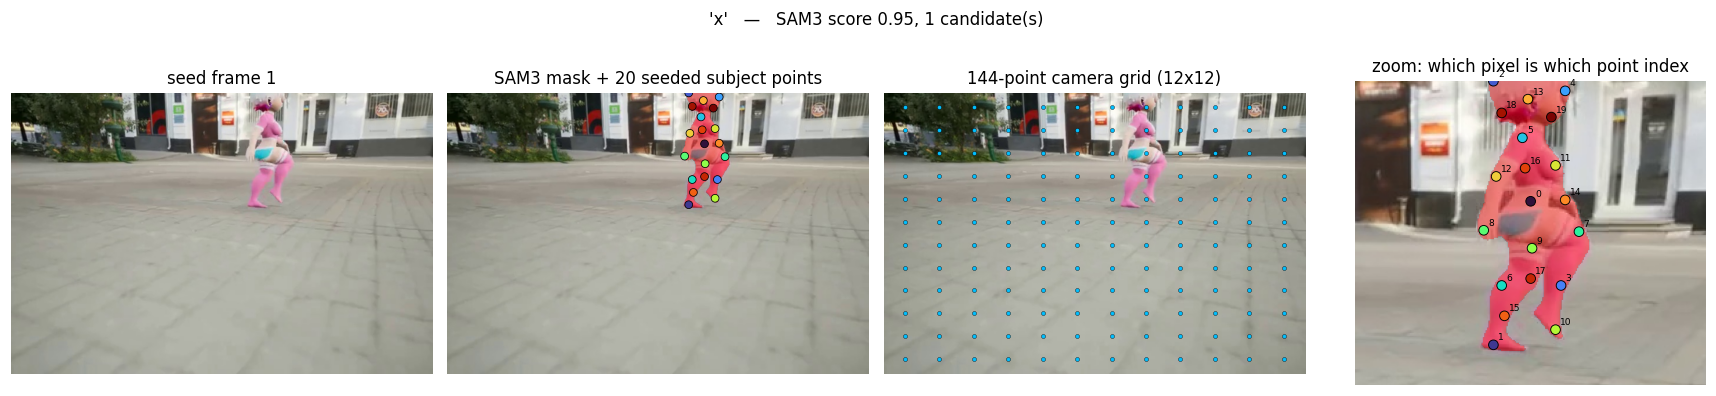

In [193]:
seed_t = points["seed_frame"]
seed_img = np.asarray(Image.open(FRAMES[seed_t]))
masks = np.load(VD / "masks" / "masks.npy")
subj_px = np.asarray(points["subject_points_px"])
grid_px = np.asarray(points["camera_grid_px"])

fig, axes = plt.subplots(1, 4, figsize=(16, 3.4))
axes[0].imshow(seed_img); axes[0].set_title(f"seed frame {seed_t}")

axes[1].imshow(seed_img)
axes[1].imshow(np.ma.masked_where(~masks[seed_t].astype(bool), masks[seed_t]),
               cmap="autumn", alpha=0.45)
axes[1].scatter(subj_px[:, 0], subj_px[:, 1], s=26, c=np.arange(P), cmap="turbo",
                edgecolors="black", linewidths=0.5, zorder=3)
axes[1].set_title(f"SAM3 mask + {P} seeded subject points")

axes[2].imshow(seed_img)
axes[2].scatter(grid_px[:, 0], grid_px[:, 1], s=7, c="deepskyblue", edgecolors="black",
                linewidths=0.25)
axes[2].set_title(f"{len(grid_px)}-point camera grid (12x12)")

ys, xs = np.nonzero(masks[seed_t].astype(bool))          # zoom, because the subject can be tiny
pad_px = 0.6 * max(xs.ptp(), ys.ptp()) + 10
x0, x1 = max(xs.mean() - pad_px, 0), min(xs.mean() + pad_px, W)
y0, y1 = max(ys.mean() - pad_px, 0), min(ys.mean() + pad_px, H)
axes[3].imshow(seed_img)
axes[3].imshow(np.ma.masked_where(~masks[seed_t].astype(bool), masks[seed_t]), cmap="autumn", alpha=0.4)
axes[3].scatter(subj_px[:, 0], subj_px[:, 1], s=40, c=np.arange(P), cmap="turbo",
                edgecolors="black", linewidths=0.6)
for i, (u, v) in enumerate(subj_px):
    axes[3].annotate(str(i), (u, v), fontsize=6, xytext=(3, 3), textcoords="offset points")
axes[3].set_xlim(x0, x1); axes[3].set_ylim(y1, y0)
axes[3].set_title("zoom: which pixel is which point index")

for ax in axes: ax.axis("off")
fig.suptitle(f"{summary['subject']!r}   —   SAM3 score {seg['chosen_score']:.2f}, "
             f"{len(seg['candidate_boxes_xyxy'])} candidate(s)", y=1.04)
plt.tight_layout(); plt.show()

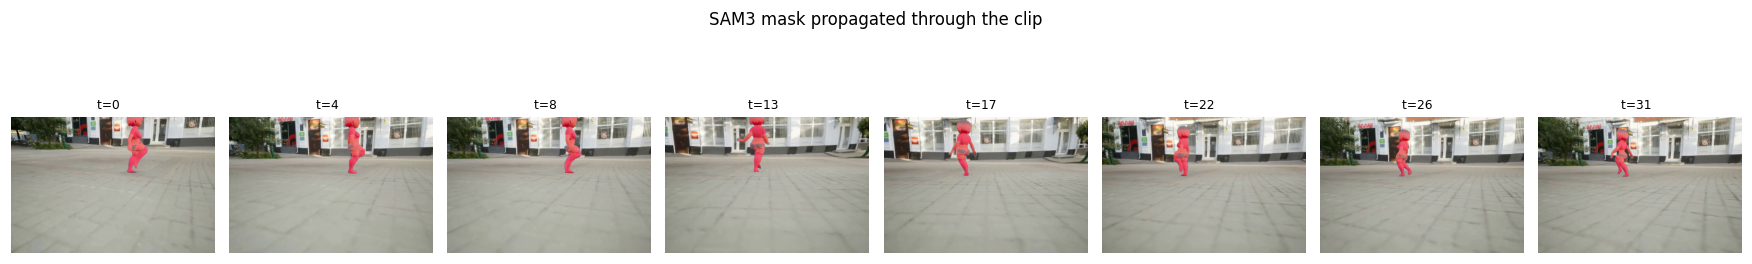

In [194]:
# The mask across time -- if SAM3 loses the subject, the tracks that follow are meaningless.
show = np.linspace(0, T - 1, 8).astype(int)
fig, axes = plt.subplots(1, len(show), figsize=(16, 2.4))
for ax, t in zip(axes, show):
    img = np.asarray(Image.open(FRAMES[t]))
    ax.imshow(img)
    m = masks[t].astype(bool)
    if m.any():
        ax.imshow(np.ma.masked_where(~m, m.astype(float)), cmap="autumn", alpha=0.45)
    ax.set_title(f"t={t}  {'' if m.any() else '(no mask)'}", fontsize=8)
    ax.axis("off")
fig.suptitle("SAM3 mask propagated through the clip", y=1.10)
plt.tight_layout(); plt.show()

## Step 1 — logits → probabilities, then gate

`visibility` and `confidence` come out of D4RT as **raw logits**: the query path used by this
pipeline sits below the layer that applies the sigmoid (`src/model/heads.py:16,19` are bare
`nn.Linear`). Thresholding them directly at 0.5 would keep essentially everything — note the
logit range printed below.

$$\sigma(x) = \frac{1}{1+e^{-x}}$$

Gate: keep a `(point, frame)` sample when it is finite **and** `σ(visibility) > 0.5` **and**
`σ(confidence) > 0.2`. The confidence cut comes from the training objective
$c\,e - 0.2\log c$, minimised at $c = 0.2/e$ — so $c = 0.2$ is "predicted error of order the
scene depth". Weight for the later median is $\sigma(\text{confidence})^2$.

In [195]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.asarray(x, dtype=np.float64)))

VISIBILITY_THRESHOLD = 0.5
CONFIDENCE_THRESHOLD = 0.2

xyz        = subject_npz["xyz_3d"].astype(np.float64)      # (P, T, 3), OpenCV camera frame of t=0
uv         = subject_npz["uv_2d"].astype(np.float64)       # (P, T, 2), normalised 0..1
visibility = sigmoid(subject_npz["visibility"])            # (P, T)
confidence = sigmoid(subject_npz["confidence"])            # (P, T)

valid   = (np.isfinite(xyz).all(axis=-1)
           & (visibility > VISIBILITY_THRESHOLD)
           & (confidence > CONFIDENCE_THRESHOLD))
weights = confidence ** 2

print(f"raw logits   visibility [{subject_npz['visibility'].min():7.2f}, {subject_npz['visibility'].max():7.2f}]"
      f"   confidence [{subject_npz['confidence'].min():7.2f}, {subject_npz['confidence'].max():7.2f}]")
print(f"probabilities visibility [{visibility.min():.3f}, {visibility.max():.3f}]"
      f"   confidence [{confidence.min():.3f}, {confidence.max():.3f}]")
print(f"\nsamples kept by the gate: {valid.sum()} / {valid.size} "
      f"({100*valid.mean():.1f}%)   -- if this is ~100%, the gate is not doing much on this clip")

raw logits   visibility [  -1.88,   10.75]   confidence [   9.69,   11.56]
probabilities visibility [0.132, 1.000]   confidence [1.000, 1.000]

samples kept by the gate: 538 / 640 (84.1%)   -- if this is ~100%, the gate is not doing much on this clip


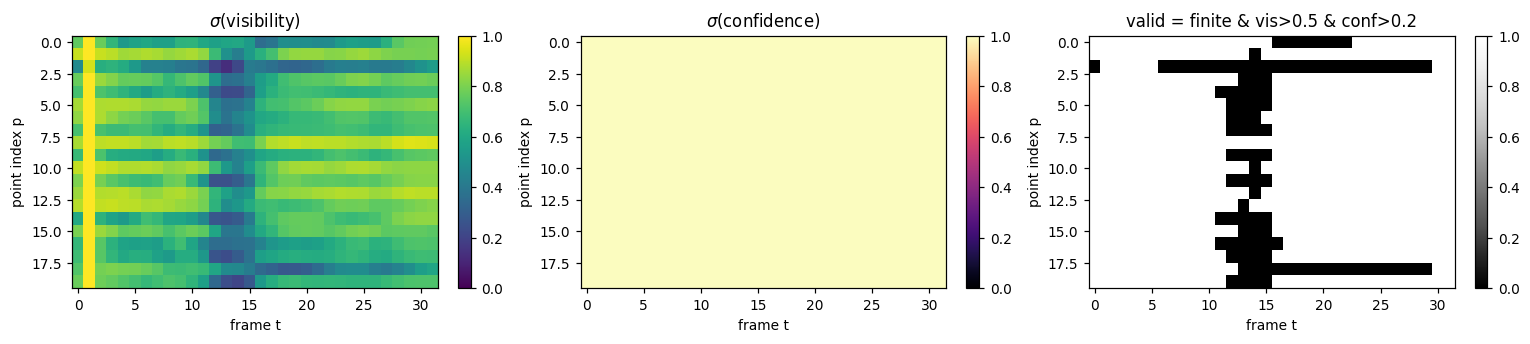

In [196]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.2))
for ax, (arr, title, kw) in zip(axes, [
        (visibility, r"$\sigma$(visibility)", dict(cmap="viridis", vmin=0, vmax=1)),
        (confidence, r"$\sigma$(confidence)", dict(cmap="magma", vmin=0, vmax=1)),
        (valid.astype(float), "valid = finite & vis>0.5 & conf>0.2", dict(cmap="Greys_r", vmin=0, vmax=1))]):
    im = ax.imshow(arr, aspect="auto", interpolation="nearest", **kw)
    ax.set_title(title); ax.set_xlabel("frame t"); ax.set_ylabel("point index p")
    ax.grid(False); fig.colorbar(im, ax=ax, fraction=0.035)
plt.tight_layout(); plt.show()

## Step 2 — the 20 raw 3D tracks

This is the input to everything that follows: 20 independent 3D trajectories, one per seeded
pixel. They are in D4RT's camera frame at `t=0` — **+x right, +y down, +z forward** — and the
units are arbitrary (the training loss normalises each clip by its own mean depth). That is why
every threshold later is a multiple of the clip's own scale rather than a distance in metres.

The spread between these 20 curves is the thing steps 4–6 exist to collapse. Look at it before it
gets averaged away.

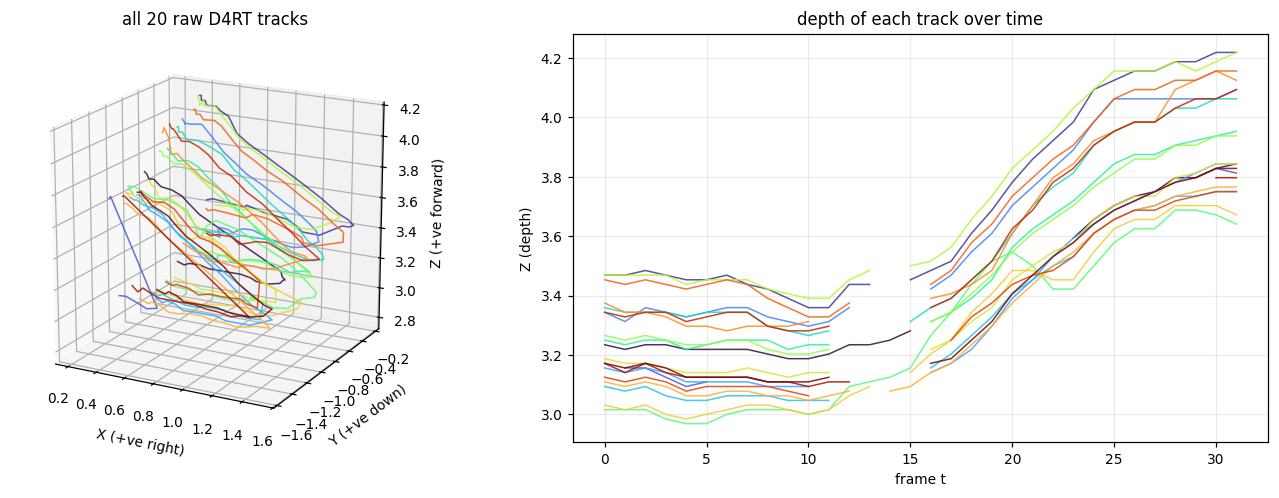

In [197]:
def equalise_3d(ax, pts):
    """Cubic bounding box -- matplotlib stretches 3D axes independently and distorts shape."""
    f = pts[np.isfinite(pts).all(axis=1)]
    if f.size == 0: return
    c, r = f.mean(axis=0), max(float(np.max(np.abs(f - f.mean(axis=0)))), 1e-6)
    ax.set_xlim(c[0]-r, c[0]+r); ax.set_ylim(c[1]-r, c[1]+r); ax.set_zlim(c[2]-r, c[2]+r)
    ax.set_box_aspect((1, 1, 1))

masked = np.where(valid[..., None], xyz, np.nan)           # (P, T, 3) with gated-out samples as NaN

fig = plt.figure(figsize=(13, 4.6))
ax = fig.add_subplot(1, 2, 1, projection="3d")
cmap = plt.get_cmap("turbo")
for p in range(P):
    ok = np.isfinite(masked[p]).all(axis=1)
    if ok.sum() > 1:
        ax.plot(*masked[p, ok].T, color=cmap(p / (P - 1)), lw=1.0, alpha=0.85)
label_3d(ax)
ax.set_title(f"all {P} raw D4RT tracks"); ax.view_init(elev=18, azim=-62)
equalise_3d(ax, masked.reshape(-1, 3))

ax2 = fig.add_subplot(1, 2, 2)
for p in range(P):
    ax2.plot(masked[p, :, 2], color=cmap(p / (P - 1)), lw=1.0, alpha=0.85)
ax2.set_xlabel("frame t"); ax2.set_ylabel("Z (depth)"); ax2.set_title("depth of each track over time")
plt.tight_layout(); plt.show()

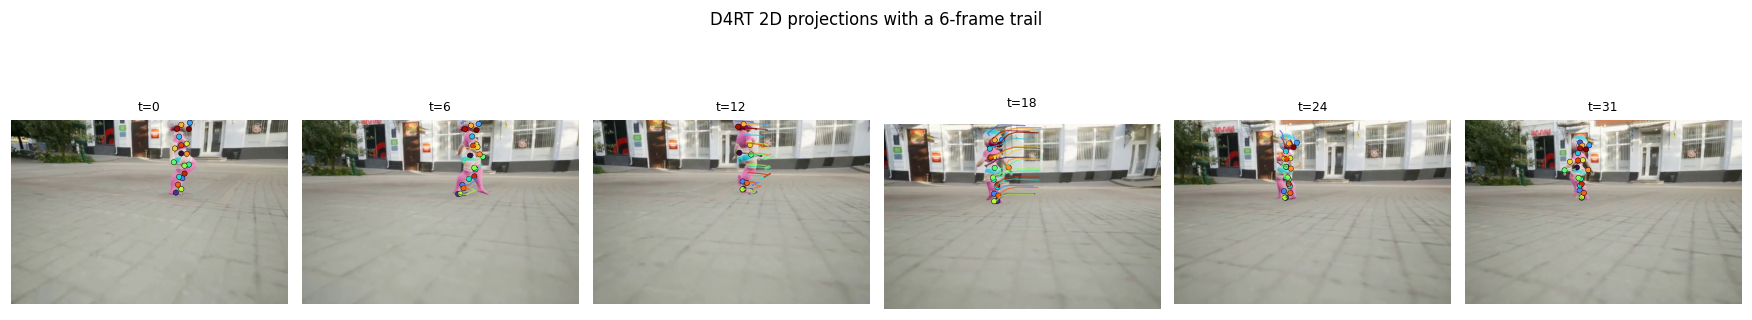

In [198]:
# The same tracks back in image space -- the honest check that they are stuck to the subject.
show = np.linspace(0, T - 1, 6).astype(int)
fig, axes = plt.subplots(1, len(show), figsize=(16, 2.9))
for ax, t in zip(axes, show):
    ax.imshow(np.asarray(Image.open(FRAMES[t])))
    for p in range(P):
        trail = uv[p, max(0, t - 6):t + 1] * [W - 1, H - 1]
        ax.plot(trail[:, 0], trail[:, 1], color=cmap(p / (P - 1)), lw=0.8, alpha=0.7)
    pts = uv[:, t] * [W - 1, H - 1]
    ax.scatter(pts[valid[:, t], 0], pts[valid[:, t], 1], s=12, c=np.arange(P)[valid[:, t]],
               cmap="turbo", vmin=0, vmax=P - 1, edgecolors="black", linewidths=0.3)
    ax.set_title(f"t={t}", fontsize=8); ax.axis("off")
fig.suptitle("D4RT 2D projections with a 6-frame trail", y=1.08)
plt.tight_layout(); plt.show()

## Step 3 — RANSAC over Kabsch: recovering the camera

`camera.npz` holds the **same** 144 world points (`t_tgt = 0`) as seen from each of the 32
viewpoints. Since both views describe identical geometry, they differ by exactly the camera's
rigid motion:

$$X_0 = T_{cw}[0]\,p_{world}, \qquad X_t = T_{cw}[t]\,p_{world}
\;\Longrightarrow\; X_0 = T_{cw}[0]\,T_{cw}[t]^{-1} X_t$$

$p_{world}$ cancels — which is why the grid points do **not** need to be static, or even off the
subject. A plain uniform grid is correct.

So for each frame we want the rigid transform $(R, t)$ with $X_0 \approx R X_t + t$.

**Kabsch** solves that in closed form for a given correspondence set (SVD of the cross-covariance,
with the reflection fix). **RANSAC** wraps it because a handful of grid points land on moving
objects or on depth discontinuities where D4RT is simply wrong, and least squares has breakdown
point 0 — one bad point drags the whole fit.

The loop: 1000 times, pick 3 points at random, fit, count how many of the other points land within
`threshold = 0.05 × cloud_scale` of their prediction, keep the largest consensus set — then refit
on it. The threshold is a fraction of the cloud's own scale, never an absolute distance.

In [199]:
def kabsch(src, dst):
    """Least-squares rigid transform with dst ~= R @ src + t.  Returns None if degenerate."""
    src, dst = np.asarray(src, float), np.asarray(dst, float)
    if src.shape != dst.shape or src.ndim != 2 or src.shape[1] != 3 or src.shape[0] < 3:
        return None
    mu_s, mu_d = src.mean(0), dst.mean(0)
    cov = ((src - mu_s).T @ (dst - mu_d)) / len(src)
    u, _, vt = np.linalg.svd(cov)
    R = vt.T @ u.T
    if np.linalg.det(R) < 0:                 # reflection fix: flip the smallest singular direction
        vt[-1] *= -1.0
        R = vt.T @ u.T
    t = mu_d - R @ mu_s
    return (R, t) if np.isfinite(R).all() and np.isfinite(t).all() else None


def cloud_scale(pts):
    """Median radius of a cloud about its median.  Every threshold below is a multiple of this."""
    pts = np.asarray(pts, float).reshape(-1, 3)
    pts = pts[np.isfinite(pts).all(axis=1)]
    if len(pts) == 0: return float("nan")
    return float(np.median(np.linalg.norm(pts - np.median(pts, axis=0), axis=1)))


def sim3_scale(src, dst):
    """Scale of the best similarity fit -- should come out ~1.0 if rigid is the right model."""
    src, dst = np.asarray(src, float), np.asarray(dst, float)
    var = float(((src - src.mean(0)) ** 2).sum() / max(len(src), 1))
    if var <= 1e-12: return float("nan")
    cov = ((src - src.mean(0)).T @ (dst - dst.mean(0))) / len(src)
    u, s, vt = np.linalg.svd(cov)
    d = np.ones(3)
    if np.linalg.det(vt.T @ u.T) < 0: d[-1] = -1.0
    return float((s * d).sum() / var)


def ransac_rigid(src, dst, weights=None, threshold_ratio=0.05, iterations=1000, seed=0, trace=False):
    """RANSAC over Kabsch.  Same sampling order as traj3d_geometry.robust_rigid, so it reproduces it."""
    src, dst = np.asarray(src, float), np.asarray(dst, float)
    ok = np.isfinite(src).all(1) & np.isfinite(dst).all(1)
    if weights is not None:
        ok &= np.asarray(weights, float) > 0
    if ok.sum() < 3: return None

    idx = np.flatnonzero(ok)
    scale = cloud_scale(dst[idx])
    if not np.isfinite(scale) or scale <= 0: return None
    threshold = threshold_ratio * scale

    rng = np.random.default_rng(seed)
    best_inliers, best_count, history = None, -1, []
    for _ in range(iterations):
        pick = rng.choice(idx, size=3, replace=False)
        fit = kabsch(src[pick], dst[pick])
        if fit is None:
            history.append(best_count); continue
        R, t = fit
        residual = np.linalg.norm((src[idx] @ R.T + t) - dst[idx], axis=1)
        inliers = residual < threshold
        if inliers.sum() > best_count:
            best_count, best_inliers = int(inliers.sum()), idx[inliers]
        history.append(best_count)

    if best_inliers is None or best_inliers.size < 3: return None
    R, t = kabsch(src[best_inliers], dst[best_inliers])          # refit on the consensus set

    residual_all = np.linalg.norm((src @ R.T + t) - dst, axis=1)
    mask = np.zeros(len(src), bool); mask[best_inliers] = True
    centred = src[best_inliers] - src[best_inliers].mean(0)
    sv = np.linalg.svd(centred, compute_uv=False)

    out = dict(rotation=R, translation=t, inliers=mask,
               rmse=float(np.sqrt(np.mean(residual_all[mask] ** 2))),
               scale=sim3_scale(src[best_inliers], dst[best_inliers]),
               conditioning=float(sv[2] / max(sv[0], 1e-12)),
               threshold=threshold, residual=residual_all)
    if trace: out["history"] = np.array(history)
    return out

frame 16: 97/144 inliers, threshold 0.0755 (= 0.05 x cloud scale), rmse 0.0399, sim3 scale 1.0091


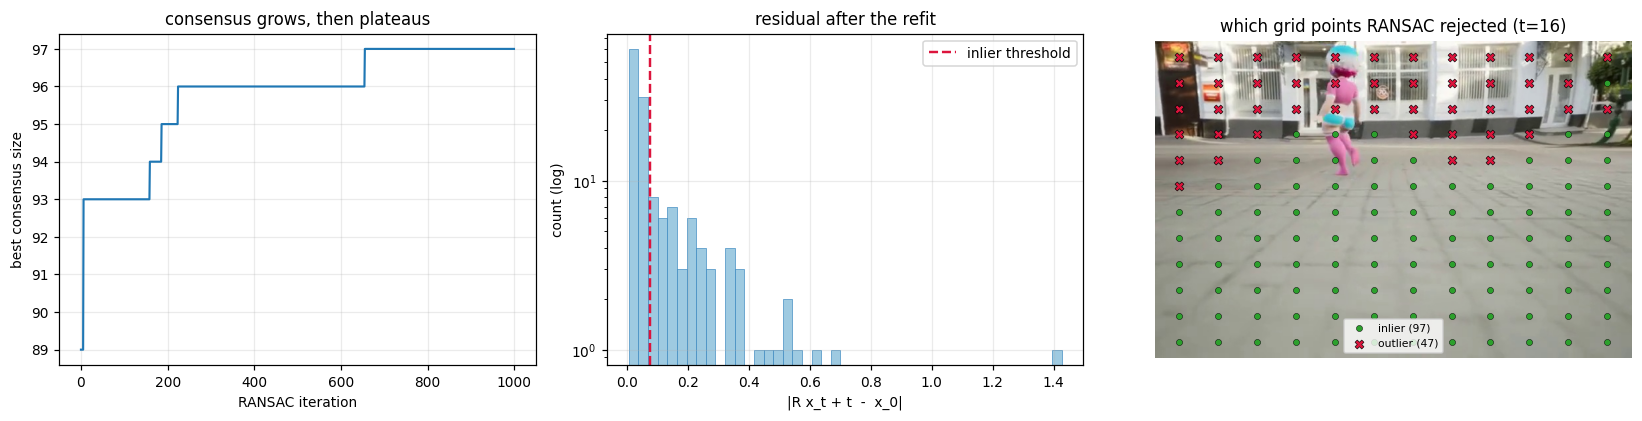

In [200]:
# One frame, in detail: how the consensus set is found and what it excludes.
cam_xyz = camera_npz["xyz_3d"].astype(np.float64)                       # (T, 144, 3)
cam_w   = np.where(sigmoid(camera_npz["visibility"]) > VISIBILITY_THRESHOLD,
                   sigmoid(camera_npz["confidence"]) ** 2, 0.0)         # (T, 144)
reference = cam_xyz[0]

DEMO_T = T // 2
demo = ransac_rigid(cam_xyz[DEMO_T], reference,
                    weights=np.minimum(cam_w[DEMO_T], cam_w[0]), seed=DEMO_T, trace=True)
print(f"frame {DEMO_T}: {demo['inliers'].sum()}/{len(demo['inliers'])} inliers, "
      f"threshold {demo['threshold']:.4f} (= 0.05 x cloud scale), rmse {demo['rmse']:.4f}, "
      f"sim3 scale {demo['scale']:.4f}")

fig = plt.figure(figsize=(15, 3.9))
ax = fig.add_subplot(1, 3, 1)
ax.plot(demo["history"], lw=1.4, color="#1f77b4")
ax.set_xlabel("RANSAC iteration"); ax.set_ylabel("best consensus size")
ax.set_title("consensus grows, then plateaus")

ax = fig.add_subplot(1, 3, 2)
res = demo["residual"][np.isfinite(demo["residual"])]
ax.hist(res, bins=45, color="#9ecae1", edgecolor="#3182bd", lw=0.4)
ax.axvline(demo["threshold"], color="crimson", lw=1.6, ls="--", label="inlier threshold")
ax.set_yscale("log"); ax.set_xlabel("|R x_t + t  -  x_0|"); ax.set_ylabel("count (log)")
ax.set_title("residual after the refit"); ax.legend()

ax = fig.add_subplot(1, 3, 3)
grid_uv = np.asarray(points["camera_grid_uv_norm"]) * [W - 1, H - 1]
ax.imshow(np.asarray(Image.open(FRAMES[DEMO_T])))
inl = demo["inliers"]
ax.scatter(grid_uv[inl, 0],  grid_uv[inl, 1],  s=16, c="#2ca02c", label=f"inlier ({inl.sum()})",
           edgecolors="black", linewidths=0.3)
ax.scatter(grid_uv[~inl, 0], grid_uv[~inl, 1], s=34, c="crimson", marker="X",
           label=f"outlier ({(~inl).sum()})", edgecolors="black", linewidths=0.4)
ax.set_title(f"which grid points RANSAC rejected (t={DEMO_T})"); ax.axis("off"); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

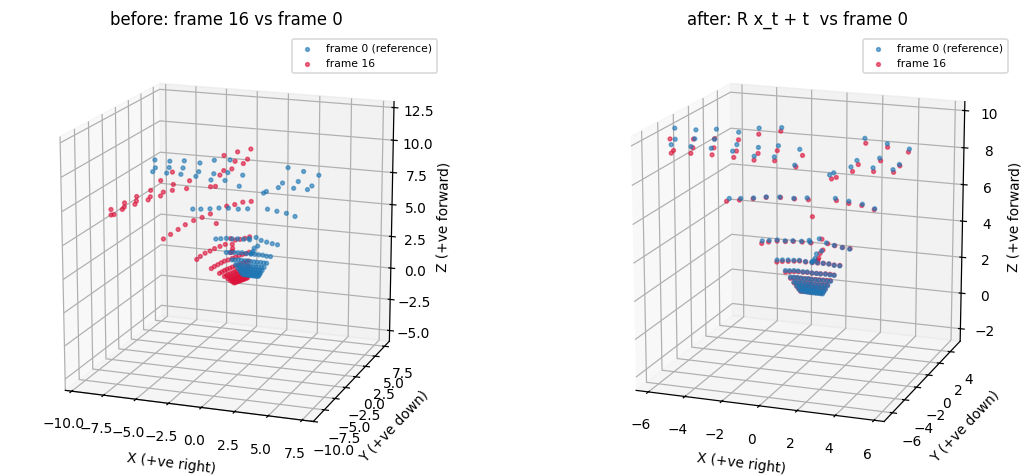

In [201]:
# The same fit seen in 3D: before alignment the two clouds are offset by the camera's motion.
R, t = demo["rotation"], demo["translation"]
aligned = cam_xyz[DEMO_T] @ R.T + t

fig = plt.figure(figsize=(11, 4.4))
for k, (src, title) in enumerate([(cam_xyz[DEMO_T], f"before: frame {DEMO_T} vs frame 0"),
                                  (aligned,          "after: R x_t + t  vs frame 0")]):
    ax = fig.add_subplot(1, 2, k + 1, projection="3d")
    ax.scatter(*reference.T, s=6, c="#1f77b4", alpha=0.6, label="frame 0 (reference)")
    ax.scatter(*src.T,       s=6, c="crimson", alpha=0.6, label=f"frame {DEMO_T}")
    ax.set_title(title); ax.view_init(elev=16, azim=-70); ax.legend(fontsize=7)
    label_3d(ax)
    equalise_3d(ax, np.vstack([reference, src]))
plt.tight_layout(); plt.show()

In [202]:
# Now every frame.  seed=t reproduces the pipeline's own RNG stream exactly.
rot   = np.tile(np.eye(3), (T, 1, 1))
trans = np.zeros((T, 3))
rmse  = np.full(T, np.nan); s3 = np.full(T, np.nan)
ninl  = np.zeros(T, int);   cond = np.full(T, np.nan)
inlier_masks = np.zeros((T, cam_xyz.shape[1]), bool)
failed = []

for tt in range(T):
    if tt == 0:
        ninl[0], rmse[0], s3[0] = int((cam_w[0] > 0).sum()), 0.0, 1.0
        continue
    fit = ransac_rigid(cam_xyz[tt], reference, weights=np.minimum(cam_w[tt], cam_w[0]), seed=tt)
    if fit is None:
        failed.append(tt); continue
    rot[tt], trans[tt] = fit["rotation"], fit["translation"]
    rmse[tt], s3[tt] = fit["rmse"], fit["scale"]
    ninl[tt], cond[tt] = int(fit["inliers"].sum()), fit["conditioning"]
    inlier_masks[tt] = fit["inliers"]

scene_scale = cloud_scale(reference)
rmse_rel = rmse / max(scene_scale, 1e-9)
cam_centres = np.einsum("tij,tj->ti", rot, np.zeros((T, 3))) + trans   # camera origin in frame-0 coords

def rotation_angle(Rm):
    return np.degrees(np.arccos(np.clip((np.trace(Rm) - 1) / 2, -1, 1)))
total_rot = sum(rotation_angle(rot[i] @ rot[i-1].T) for i in range(1, T))

print(f"scene scale {scene_scale:.4f}   median relative rmse {np.nanmedian(rmse_rel[1:]):.4f}"
      f"   median sim3 scale {np.nanmedian(s3[1:]):.4f}")
print(f"min inliers {ninl[1:].min()}/{cam_xyz.shape[1]}   total camera rotation {total_rot:.2f} deg"
      f"   failed frames {failed or 'none'}")

scene scale 1.5106   median relative rmse 0.0259   median sim3 scale 1.0061
min inliers 93/144   total camera rotation 58.62 deg   failed frames none


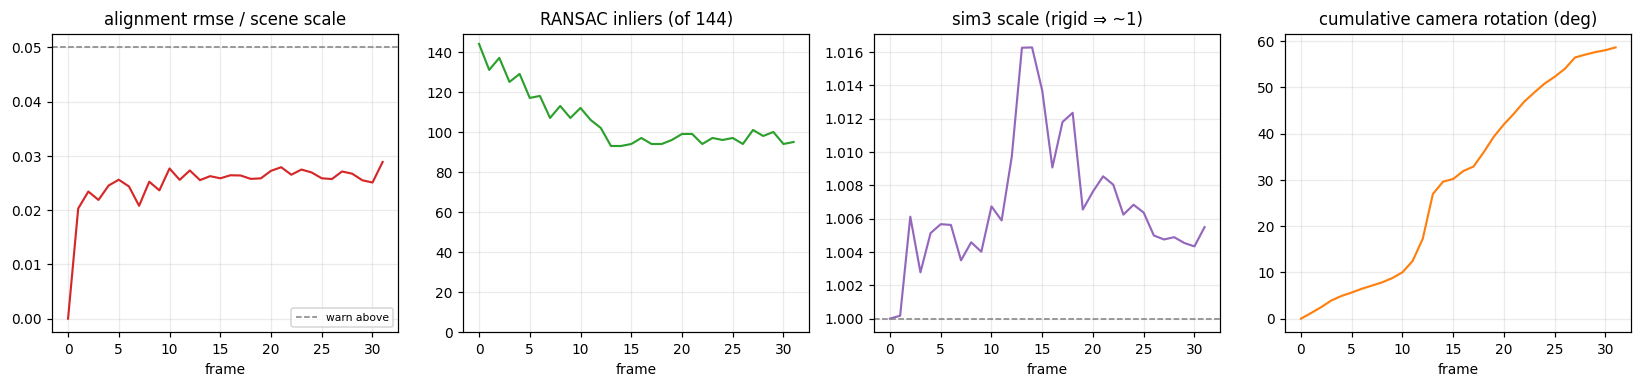

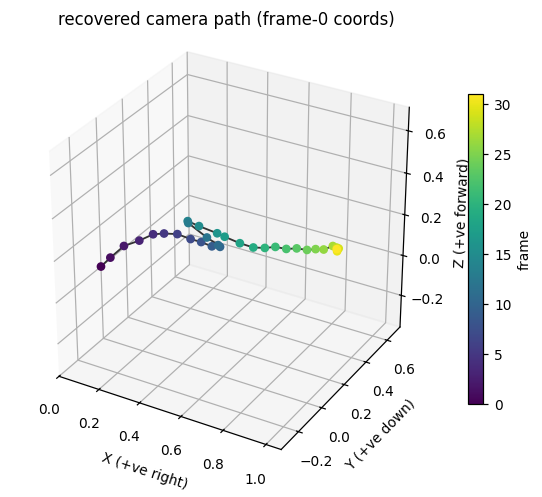

In [203]:
fig = plt.figure(figsize=(15, 3.6))
ax = fig.add_subplot(1, 4, 1); ax.plot(rmse_rel, lw=1.4, color="#d62728")
ax.axhline(0.05, ls="--", lw=1, color="grey", label="warn above")
ax.set_xlabel("frame"); ax.set_title("alignment rmse / scene scale"); ax.legend(fontsize=7)

ax = fig.add_subplot(1, 4, 2); ax.plot(ninl, lw=1.4, color="#2ca02c")
ax.set_ylim(0, cam_xyz.shape[1] + 5); ax.set_xlabel("frame"); ax.set_title("RANSAC inliers (of 144)")

ax = fig.add_subplot(1, 4, 3); ax.plot(s3, lw=1.4, color="#9467bd")
ax.axhline(1.0, ls="--", lw=1, color="grey")
ax.set_xlabel("frame"); ax.set_title("sim3 scale (rigid ⇒ ~1)")

ax = fig.add_subplot(1, 4, 4)
ang = [0.0] + [rotation_angle(rot[i] @ rot[i-1].T) for i in range(1, T)]
ax.plot(np.cumsum(ang), lw=1.4, color="#ff7f0e")
ax.set_xlabel("frame"); ax.set_title("cumulative camera rotation (deg)")
plt.tight_layout(); plt.show()

fig = plt.figure(figsize=(5.4, 4.4))
ax = fig.add_subplot(projection="3d")
ax.plot(*cam_centres.T, color="#333333", lw=1.2)
sc = ax.scatter(*cam_centres.T, c=np.arange(T), cmap="viridis", s=22, depthshade=False)
ax.set_title("recovered camera path (frame-0 coords)")
label_3d(ax)
equalise_3d(ax, cam_centres); fig.colorbar(sc, ax=ax, label="frame", fraction=0.03)
plt.tight_layout(); plt.show()

### The camera path, one axis at a time

The 3D path above is easy to look at and hard to read numbers off. Here are the same camera
centres split into the three axes the subject plots use — **+x right, +y down, +z forward**, in
D4RT units — plus the same Savitzky–Golay filter that step 6 applies to the subject trajectory.

The grey curve is the raw per-frame RANSAC translation. Every frame was fitted against frame 0
*independently*: there is no temporal term anywhere in `robust_rigid`, no prior linking frame $t$
to frame $t-1$. So wobble in the grey curve is estimation noise, not camera shake — a real camera
cannot change direction between adjacent frames the way a bad fit can. That is exactly what makes
the raw-vs-smoothed gap worth reading: it is a noise estimate for the camera fit.

Compare the axes by their *printed ranges*, not by how ragged they look. Each panel is
autoscaled, so an axis the camera barely moved along is drawn at enormous magnification and its
noise fills the panel — it looks like the worst-estimated axis when it is really just the
smallest one. The range line below the figure is what tells you which is which.

Two things this is *not*:

* **It is not fed back.** `cam_smooth` is diagnostic only. Nothing downstream consumes it, and the
  step 8 verification still compares the raw `rot`/`trans` against what the pipeline wrote.
* **It is translation only.** Rotations cannot go through a Savitzky–Golay filter as matrices — a
  per-element polynomial fit of nine entries leaves $R^\top R = I$ broken. Smoothing those
  properly needs SLERP over quaternions, which the pipeline does not do either.

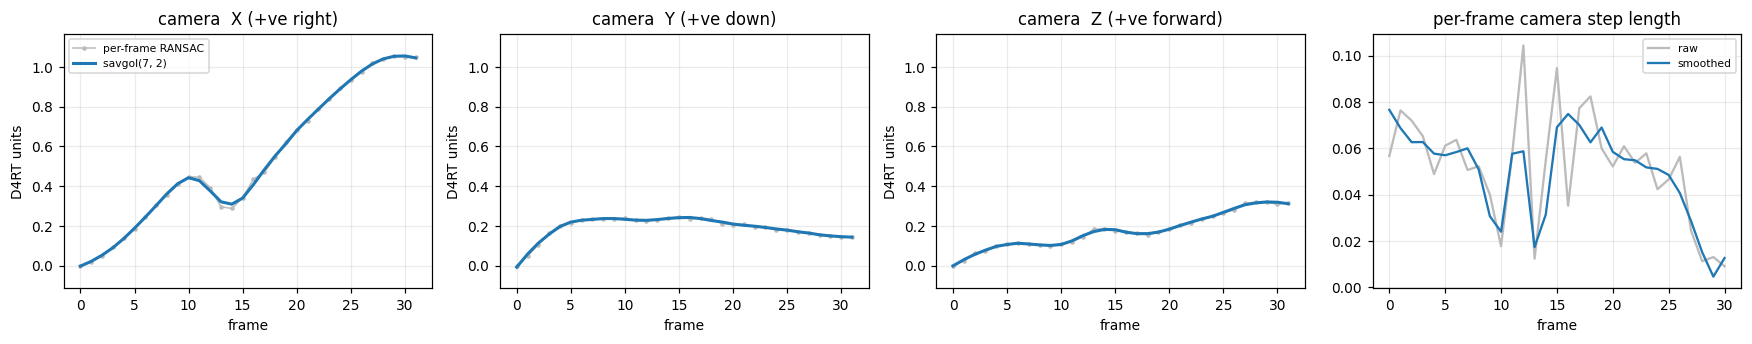

camera X (+ve right)      range  1.0525   =   0.70 x scene scale
camera Y (+ve down)       range  0.2440   =   0.16 x scene scale
camera Z (+ve forward)    range  0.3181   =   0.21 x scene scale

path length   raw 1.6095  ->  smoothed 1.5402   (4.3% shorter)
rms jerk      raw 0.0352  ->  smoothed 0.0203   (42.4% lower)

A large drop means the per-frame fits disagree with each other frame to frame, i.e. the
camera estimate is noisy.  A small drop means the fits were already temporally coherent.


In [204]:
from scipy.signal import savgol_filter

def smooth_trajectory(track, window=7, polyorder=2):
    """Savitzky-Golay per coordinate.  Gaps are linearly interpolated so the filter sees a
    continuous signal, then restored to NaN so absent frames stay absent.

    Defined here because the camera path needs it first; step 6 applies this same function
    to the subject trajectory."""
    track = np.asarray(track, float)
    finite = np.isfinite(track).all(axis=1)
    if finite.sum() < max(window, polyorder + 2):
        return track.copy()
    filled = track.copy()
    if not finite.all():
        i = np.arange(len(track))
        for a in range(3):
            filled[:, a] = np.interp(i, i[finite], track[finite, a])
    window = min(window, len(filled) if len(filled) % 2 == 1 else len(filled) - 1)
    if window <= polyorder:
        return track.copy()
    out = savgol_filter(filled, window_length=window, polyorder=polyorder, axis=0, mode="interp")
    out[~finite] = np.nan
    return out

cam_track = cam_centres.copy()
cam_track[failed] = np.nan          # a failed fit leaves trans = 0, which is not a measurement
cam_smooth = smooth_trajectory(cam_track)

AXIS = AX
fig, axes = plt.subplots(1, 4, figsize=(16, 3.2))
for ax, k in zip(axes, range(3)):
    ax.plot(cam_track[:, k],  lw=1.0, color="#bbbbbb", marker=".", ms=4, label="per-frame RANSAC")
    ax.plot(cam_smooth[:, k], lw=2.0, color="#1f77b4", label="savgol(7, 2)")
    ax.set_xlabel("frame"); ax.set_ylabel("D4RT units")
    ax.set_title(f"camera  {AXIS[k]}")
    if k == 0: ax.legend(fontsize=7)
lock_axes(axes[:3])                       # X, Y, Z share one scale; the step-length panel does not
axes[3].plot(np.linalg.norm(np.diff(cam_track,  axis=0), axis=1), color="#bbbbbb", label="raw")
axes[3].plot(np.linalg.norm(np.diff(cam_smooth, axis=0), axis=1), color="#1f77b4", label="smoothed")
axes[3].set_xlabel("frame"); axes[3].set_title("per-frame camera step length"); axes[3].legend(fontsize=7)
plt.tight_layout(); plt.show()

def jerk(track):                     # rms second difference -- frame-to-frame incoherence
    d2 = np.diff(track, n=2, axis=0)
    d2 = d2[np.isfinite(d2).all(axis=1)]
    return float(np.sqrt((d2 ** 2).sum(axis=1).mean())) if len(d2) else np.nan

def plen(track):
    d = np.diff(track, axis=0)
    d = d[np.isfinite(d).all(axis=1)]
    return float(np.linalg.norm(d, axis=1).sum())

for k, nm in enumerate(AXIS):
    col = cam_track[:, k][np.isfinite(cam_track[:, k])]
    print(f"camera {nm:18s} range {col.max() - col.min():7.4f}   "
          f"= {(col.max() - col.min()) / scene_scale:6.2f} x scene scale")
print(f"\npath length   raw {plen(cam_track):.4f}  ->  smoothed {plen(cam_smooth):.4f}"
      f"   ({100 * (1 - plen(cam_smooth) / max(plen(cam_track), 1e-9)):.1f}% shorter)")
print(f"rms jerk      raw {jerk(cam_track):.4f}  ->  smoothed {jerk(cam_smooth):.4f}"
      f"   ({100 * (1 - jerk(cam_smooth) / max(jerk(cam_track), 1e-9)):.1f}% lower)")
print("\nA large drop means the per-frame fits disagree with each other frame to frame, i.e. the")
print("camera estimate is noisy.  A small drop means the fits were already temporally coherent.")

### Which grid points is the camera fit actually listening to?

Worth checking, because the grid is uniform over the *stored* frame — and these clips are
letterboxed. A grid point on a black bar has no image content behind it, so whatever depth D4RT
invents for it is near-constant across frames, which makes it a perfect rigid inlier. If most of
the consensus set is padding, the recovered "camera motion" is largely the statement that the
padding did not move, and the low residual is not evidence that the fit is right.

Nothing in `traj3d_analyze.py` looks at this, and it does not trip the rmse warning — padding fits
*better* than real content, so it pushes the residual down.

In [205]:
lum = np.stack([np.asarray(Image.open(f).convert("L"), dtype=float) for f in FRAMES])  # (T, H, W)
gi = np.round(grid_px).astype(int)
gi[:, 0] = np.clip(gi[:, 0], 0, W - 1); gi[:, 1] = np.clip(gi[:, 1], 0, H - 1)
is_pad = (lum[:, gi[:, 1], gi[:, 0]] < 12).all(axis=0)          # dark in every frame -> letterbox

if is_pad.sum() == 0:
    print("no letterbox padding on this clip -- every grid point sits on real image content")
else:
    rate_pad = inlier_masks[1:][:, is_pad].mean(axis=1)
    rate_con = inlier_masks[1:][:, ~is_pad].mean(axis=1)
    print(f"{is_pad.sum()}/{len(is_pad)} grid points sit on black padding")
    print(f"mean inlier rate   padding {rate_pad.mean():.2f}   image content {rate_con.mean():.2f}")
    print(f"depth std over frames   padding {np.nanstd(cam_xyz[:, is_pad, 2]):.3f}"
          f"   image content {np.nanstd(cam_xyz[:, ~is_pad, 2]):.3f}")
    frac = inlier_masks[1:][:, is_pad].sum(axis=1) / np.maximum(inlier_masks[1:].sum(axis=1), 1)
    print(f"share of the consensus set that is padding: {frac.mean():.0%}")

    fig, axes = plt.subplots(1, 3, figsize=(14, 3.4))
    axes[0].imshow(np.asarray(Image.open(FRAMES[seed_t])))
    axes[0].scatter(grid_px[is_pad, 0], grid_px[is_pad, 1], s=14, c="#ff7f0e", label="padding",
                    edgecolors="black", linewidths=0.3)
    axes[0].scatter(grid_px[~is_pad, 0], grid_px[~is_pad, 1], s=14, c="#1f77b4", label="content",
                    edgecolors="black", linewidths=0.3)
    axes[0].axis("off"); axes[0].set_title("grid points by what is behind them"); axes[0].legend(fontsize=7)

    axes[1].plot(np.arange(1, T), rate_pad, lw=1.5, color="#ff7f0e", label="padding")
    axes[1].plot(np.arange(1, T), rate_con, lw=1.5, color="#1f77b4", label="image content")
    axes[1].set_ylim(0, 1.05); axes[1].set_xlabel("frame"); axes[1].set_ylabel("fraction kept as inlier")
    axes[1].set_title("who survives the consensus test"); axes[1].legend(fontsize=7)

    axes[2].plot(np.arange(1, T), frac, lw=1.5, color="#d62728")
    axes[2].axhline(is_pad.mean(), ls="--", lw=1, color="grey", label="share of the grid that is padding")
    axes[2].set_ylim(0, 1.05); axes[2].set_xlabel("frame")
    axes[2].set_title("share of the consensus set that is padding"); axes[2].legend(fontsize=7)
    plt.tight_layout(); plt.show()

no letterbox padding on this clip -- every grid point sits on real image content


## Step 4 — rejecting whole tracks

Rejection happens at **track** level, not per frame. The reasoning matters:

* a bad D4RT point latched onto the wrong surface *when it was seeded*, so it is wrong for its
  entire track;
* the subject is non-rigid, so a per-frame consensus would swap physical identity between frames —
  a swinging forearm is an inlier in some frames and an outlier in others — producing a jittery
  trajectory with a wandering bias.

Three tests, applied in order, each on the surviving set. `scale` below is the subject cloud's own
`cloud_scale`.

| Test | Question | Reject when |
|---|---|---|
| **B1 membership** | is the point even on the subject? | median distance to the per-frame centre > `3 × scale` |
| **B2 bulk motion** | does it translate *with* the subject? | displacement disagrees with consensus at lags 4/8/16/31 by > `2 × scale`, or > median + 3·MAD |
| **B3 smoothness** | does it flicker? | second difference > median + 3·MAD |

B2 is evaluated at long lags on purpose: at lag 1 limb swing dominates and the test over-rejects.

In [206]:
def mad(v):
    """Median absolute deviation, scaled so it estimates sigma for a normal."""
    v = np.asarray(v, float); v = v[np.isfinite(v)]
    return float("nan") if v.size == 0 else float(1.4826 * np.median(np.abs(v - np.median(v))))

MEMBERSHIP_RATIO, MOTION_RATIO, LAGS = 3.0, 2.0, (4, 8, 16, 31)

centre = np.nanmedian(masked, axis=0)                                   # (T, 3) per-frame centroid
scale  = cloud_scale(masked[np.isfinite(masked).all(axis=-1)])
keep   = np.ones(P, bool)
reasons = {"membership": [], "bulk_motion": [], "smoothness": []}
print(f"subject cloud scale = {scale:.4f}  (all thresholds below are multiples of this)")

subject cloud scale = 0.5459  (all thresholds below are multiples of this)


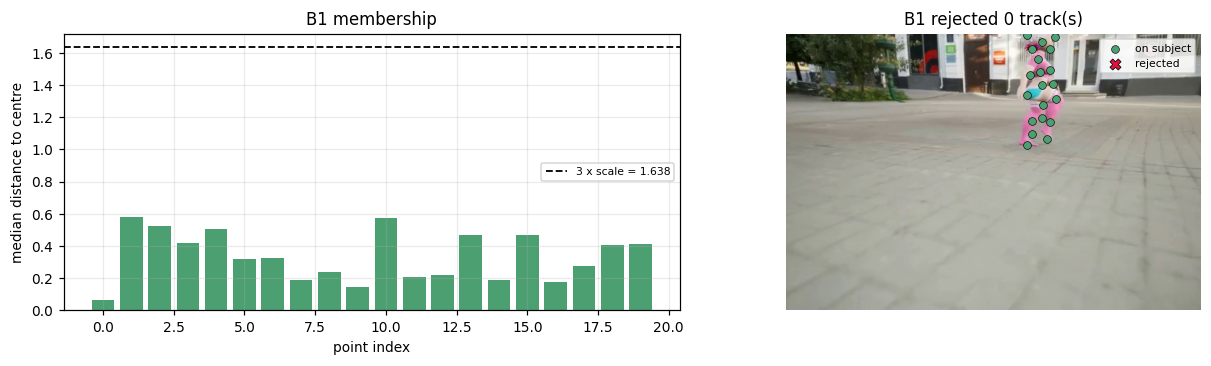

In [207]:
# --- B1: membership ------------------------------------------------------
radius = np.nanmedian(np.linalg.norm(masked - centre[None], axis=-1), axis=1)   # (P,)
reject = np.nan_to_num(radius, nan=np.inf) > MEMBERSHIP_RATIO * scale
reasons["membership"] = np.flatnonzero(reject).tolist()
keep &= ~reject

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
axes[0].bar(np.arange(P), radius, color=np.where(reject, "crimson", "#4c9f70"))
axes[0].axhline(MEMBERSHIP_RATIO * scale, ls="--", color="black", lw=1.2,
                label=f"3 x scale = {MEMBERSHIP_RATIO*scale:.3f}")
axes[0].set_xlabel("point index"); axes[0].set_ylabel("median distance to centre")
axes[0].set_title("B1 membership"); axes[0].legend(fontsize=7)

axes[1].imshow(np.asarray(Image.open(FRAMES[seed_t])))
pts_seed = uv[:, seed_t] * [W - 1, H - 1]
axes[1].scatter(pts_seed[~reject, 0], pts_seed[~reject, 1], s=26, c="#4c9f70",
                edgecolors="black", linewidths=0.4, label="on subject")
axes[1].scatter(pts_seed[reject, 0], pts_seed[reject, 1], s=52, c="crimson", marker="X",
                edgecolors="black", linewidths=0.5, label="rejected")
axes[1].axis("off"); axes[1].set_title(f"B1 rejected {reject.sum()} track(s)"); axes[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

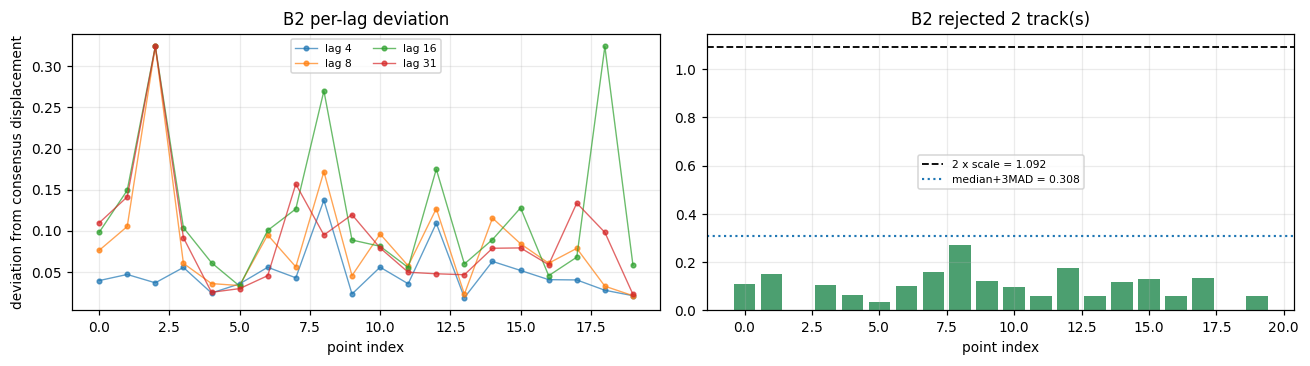

In [208]:
# --- B2: does the track translate with the subject? ----------------------
motion_residual = np.zeros(P)
per_lag = {}
for lag in LAGS:
    if lag >= T: continue
    delta = masked[:, lag:] - masked[:, :-lag]                  # (P, T-lag, 3) displacement over `lag`
    consensus = np.nanmedian(delta, axis=0)                     # what the subject as a whole did
    dev = np.nanmedian(np.linalg.norm(delta - consensus[None], axis=-1), axis=1)
    per_lag[lag] = np.nan_to_num(dev, nan=np.inf)
    motion_residual = np.maximum(motion_residual, per_lag[lag])

reject = motion_residual > MOTION_RATIO * scale
mad_cutoff = np.nan
if keep.sum() > 2:
    mad_cutoff = np.nanmedian(motion_residual[keep]) + 3.0 * mad(motion_residual[keep])
    if np.isfinite(mad_cutoff):
        reject |= motion_residual > mad_cutoff
reasons["bulk_motion"] = np.flatnonzero(reject & keep).tolist()
keep &= ~reject

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
for lag, dev in per_lag.items():
    axes[0].plot(np.clip(dev, 0, np.nanmax(motion_residual[np.isfinite(motion_residual)]) * 1.2),
                 marker="o", ms=3, lw=0.9, alpha=0.7, label=f"lag {lag}")
axes[0].set_xlabel("point index"); axes[0].set_ylabel("deviation from consensus displacement")
axes[0].set_title("B2 per-lag deviation"); axes[0].legend(fontsize=7, ncol=2)

axes[1].bar(np.arange(P), np.clip(motion_residual, 0, np.inf),
            color=np.where(reject, "crimson", "#4c9f70"))
axes[1].axhline(MOTION_RATIO * scale, ls="--", color="black", lw=1.2, label=f"2 x scale = {MOTION_RATIO*scale:.3f}")
if np.isfinite(mad_cutoff):
    axes[1].axhline(mad_cutoff, ls=":", color="#1f77b4", lw=1.4, label=f"median+3MAD = {mad_cutoff:.3f}")
axes[1].set_xlabel("point index"); axes[1].set_title(f"B2 rejected {len(reasons['bulk_motion'])} track(s)")
axes[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

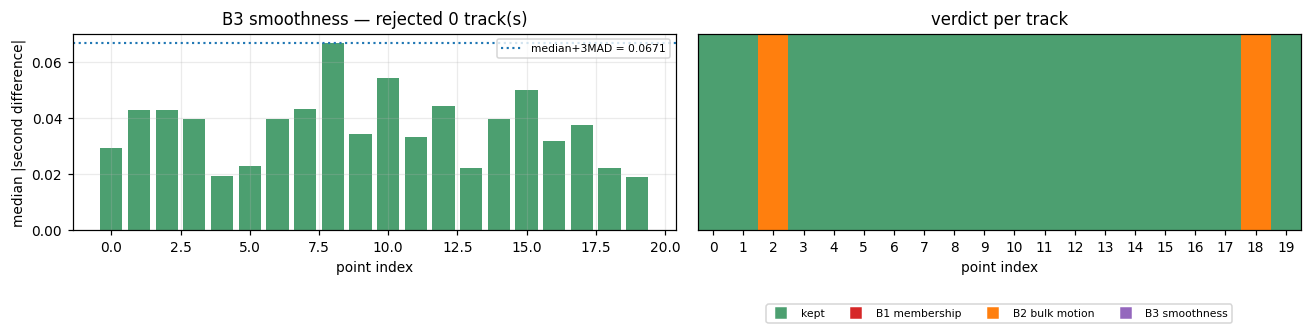

kept 18/20 tracks   rejected: {'membership': [], 'bulk_motion': [2, 18], 'smoothness': []}


In [209]:
# --- B3: flicker ---------------------------------------------------------
second = masked[:, 2:] - 2.0 * masked[:, 1:-1] + masked[:, :-2]      # discrete acceleration
jitter = np.nanmedian(np.linalg.norm(second, axis=-1), axis=1)
jitter_cutoff = np.nan
if keep.sum() > 2:
    jitter_cutoff = np.nanmedian(jitter[keep]) + 3.0 * mad(jitter[keep])
    if np.isfinite(jitter_cutoff):
        reject = np.nan_to_num(jitter, nan=np.inf) > jitter_cutoff
        reasons["smoothness"] = np.flatnonzero(reject & keep).tolist()
        keep &= ~reject

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
axes[0].bar(np.arange(P), jitter, color=["crimson" if p in reasons["smoothness"] else "#4c9f70" for p in range(P)])
if np.isfinite(jitter_cutoff):
    axes[0].axhline(jitter_cutoff, ls=":", color="#1f77b4", lw=1.4, label=f"median+3MAD = {jitter_cutoff:.4f}")
    axes[0].legend(fontsize=7)
axes[0].set_xlabel("point index"); axes[0].set_ylabel("median |second difference|")
axes[0].set_title(f"B3 smoothness — rejected {len(reasons['smoothness'])} track(s)")

status = np.zeros(P)
for r, code_ in (("membership", 1), ("bulk_motion", 2), ("smoothness", 3)):
    status[reasons[r]] = code_
axes[1].imshow(status[None], aspect="auto", cmap=mcolors.ListedColormap(
    ["#4c9f70", "#d62728", "#ff7f0e", "#9467bd"]), vmin=0, vmax=3)
axes[1].set_yticks([]); axes[1].set_xticks(range(P)); axes[1].set_xlabel("point index")
axes[1].grid(False); axes[1].set_title("verdict per track")
axes[1].legend(handles=[Line2D([], [], marker="s", ls="", color=c, label=l) for c, l in
                        [("#4c9f70", "kept"), ("#d62728", "B1 membership"),
                         ("#ff7f0e", "B2 bulk motion"), ("#9467bd", "B3 smoothness")]],
               fontsize=7, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.35))
plt.tight_layout(); plt.show()

print(f"kept {keep.sum()}/{P} tracks   rejected: {reasons}")

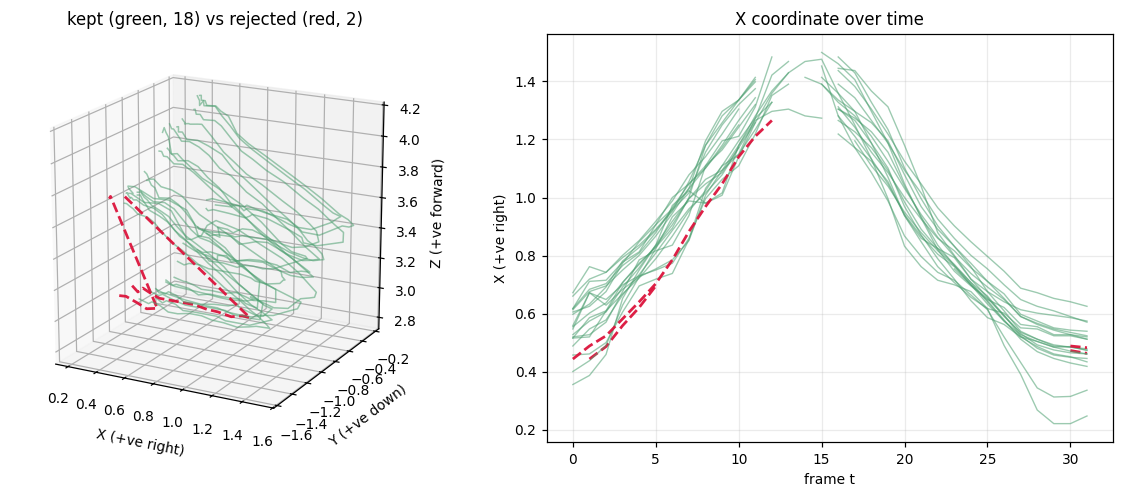

In [210]:
# What survived, in 3D.
fig = plt.figure(figsize=(11, 4.6))
ax = fig.add_subplot(1, 2, 1, projection="3d")
for p in range(P):
    ok = np.isfinite(masked[p]).all(axis=1)
    if ok.sum() < 2: continue
    ax.plot(*masked[p, ok].T, color=("#4c9f70" if keep[p] else "crimson"),
            lw=(1.0 if keep[p] else 1.8), alpha=(0.55 if keep[p] else 0.95),
            ls=("-" if keep[p] else "--"))
ax.set_title(f"kept (green, {keep.sum()}) vs rejected (red, {(~keep).sum()})")
label_3d(ax); ax.view_init(elev=18, azim=-62)
equalise_3d(ax, masked.reshape(-1, 3))

ax = fig.add_subplot(1, 2, 2)
for p in range(P):
    ax.plot(masked[p, :, 0], color=("#4c9f70" if keep[p] else "crimson"),
            lw=(0.9 if keep[p] else 1.8), alpha=(0.55 if keep[p] else 0.95),
            ls=("-" if keep[p] else "--"))
ax.set_xlabel("frame t"); ax.set_ylabel(AX[0]); ax.set_title("X coordinate over time")
plt.tight_layout(); plt.show()

## Step 5 — the median: one point per frame

For each frame, collapse the surviving tracks into a single position. The pipeline uses the
**weighted geometric median** (the L1 multivariate median), computed with Weiszfeld's algorithm:

$$c \leftarrow \frac{\sum_i w_i\,x_i / \lVert x_i - c\rVert}{\sum_i w_i / \lVert x_i - c\rVert}$$

with $w_i = \sigma(\text{confidence})^2$. It minimises the sum of *distances*, not squared
distances.

Why not the alternatives:

* the **mean** has breakdown point 0 — a single bad track moves it;
* the **per-coordinate median** is not rotation-equivariant, so the answer would depend on the
  arbitrary orientation of the camera frame.

With fewer than 4 points the implementation falls back to the per-coordinate median (Weiszfeld
is not worth it there).

In [211]:
def geometric_median(pts, w=None, iters=64, eps=1e-9, trace=False):
    """Weighted L1 multivariate median via Weiszfeld iteration."""
    pts = np.asarray(pts, float)
    if len(pts) == 0: return (np.full(3, np.nan), []) if trace else np.full(3, np.nan)
    w = np.ones(len(pts)) if w is None else np.asarray(w, float)
    if len(pts) < 4:
        m = np.median(pts, axis=0)
        return (m, [m]) if trace else m

    c = np.average(pts, axis=0, weights=w)        # start from the weighted mean
    history = [c.copy()]
    for _ in range(iters):
        d = np.maximum(np.linalg.norm(pts - c, axis=1), eps)
        ww = w / d                                # closer points pull harder
        nxt = (pts * ww[:, None]).sum(0) / ww.sum()
        history.append(nxt.copy())
        if np.linalg.norm(nxt - c) < eps * (1.0 + np.linalg.norm(c)):
            c = nxt; break
        c = nxt
    return (c, np.array(history)) if trace else c

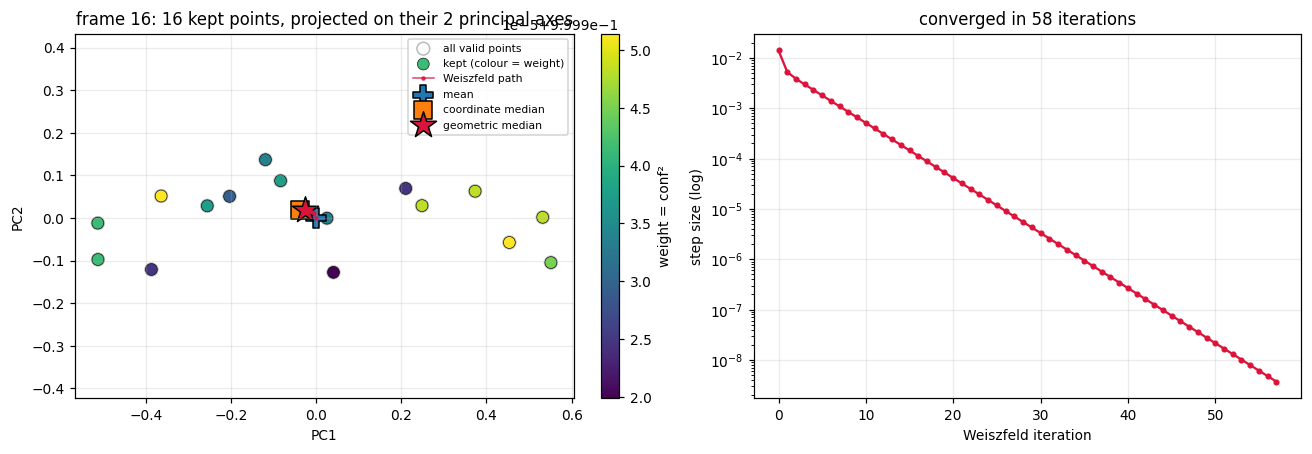

mean               [ 1.3481 -0.807   3.3057]
coordinate median  [ 1.332  -0.7695  3.3125]
geometric median   [ 1.3312 -0.7786  3.306 ]    (moved 0.0331 off the mean)


In [212]:
# One frame in close-up: mean vs coordinate median vs geometric median, and the Weiszfeld path.
DEMO_F = T // 2
frame_valid = valid[:, DEMO_F] & np.isfinite(xyz[:, DEMO_F]).all(axis=-1)
sel = frame_valid & keep
pts, wts = xyz[sel, DEMO_F], weights[sel, DEMO_F]
gm, hist = geometric_median(pts, wts, trace=True)

# project on the cloud's two principal axes so the picture is not an arbitrary slice
c0 = pts.mean(0)
basis = np.linalg.svd(pts - c0, full_matrices=False)[2][:2]
proj = lambda X: (np.atleast_2d(X) - c0) @ basis.T

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
ax = axes[0]
allp = xyz[frame_valid, DEMO_F]
ax.scatter(*proj(allp).T, s=70, facecolors="none", edgecolors="#bbbbbb", label="all valid points")
sc = ax.scatter(*proj(pts).T, s=60, c=wts, cmap="viridis", edgecolors="black", linewidths=0.4,
                label="kept (colour = weight)")
ax.plot(*proj(hist).T, color="crimson", lw=1.0, marker=".", ms=4, alpha=0.8, label="Weiszfeld path")
ax.scatter(*proj(pts.mean(0)).T, marker="P", s=170, c="#1f77b4", edgecolors="black", label="mean")
ax.scatter(*proj(np.median(allp, axis=0)).T, marker="s", s=130, c="#ff7f0e", edgecolors="black",
           label="coordinate median")
ax.scatter(*proj(gm).T, marker="*", s=320, c="crimson", edgecolors="black", label="geometric median")
ax.set_title(f"frame {DEMO_F}: {sel.sum()} kept points, projected on their 2 principal axes")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.legend(fontsize=7, framealpha=0.85)
ax.set_aspect("equal", adjustable="datalim")     # equal scale, but fill the box
fig.colorbar(sc, ax=ax, fraction=0.04, label="weight = conf²")

ax = axes[1]
ax.semilogy(np.linalg.norm(np.diff(hist, axis=0), axis=1), marker="o", ms=3, color="crimson")
ax.set_xlabel("Weiszfeld iteration"); ax.set_ylabel("step size (log)")
ax.set_title(f"converged in {len(hist)-1} iterations")
plt.tight_layout(); plt.show()

print("mean              ", pts.mean(0))
print("coordinate median ", np.median(allp, axis=0))
print("geometric median  ", gm, f"   (moved {np.linalg.norm(gm - pts.mean(0)):.4f} off the mean)")

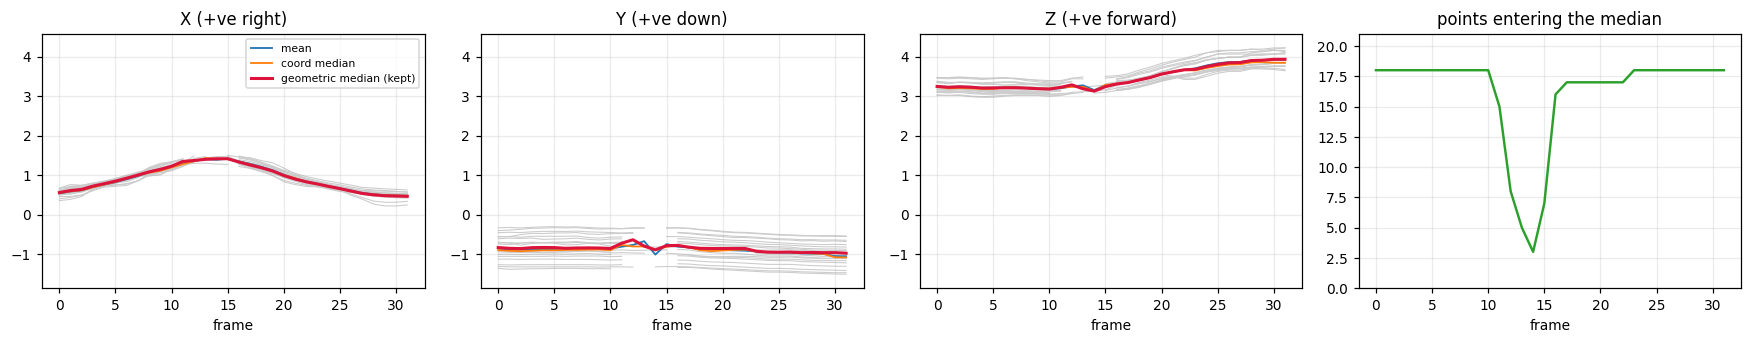

In [213]:
# Now every frame -- this is aggregate_trajectory().
agg = {"mean": np.full((T, 3), np.nan), "median": np.full((T, 3), np.nan),
       "ransac_median": np.full((T, 3), np.nan), "n_inliers": np.zeros(T, int)}
for tt in range(T):
    fv = valid[:, tt] & np.isfinite(xyz[:, tt]).all(axis=-1)
    if fv.any():
        agg["mean"][tt]   = xyz[fv, tt].mean(axis=0)
        agg["median"][tt] = np.median(xyz[fv, tt], axis=0)
    s = fv & keep
    agg["n_inliers"][tt] = int(s.sum())
    if s.any():
        agg["ransac_median"][tt] = geometric_median(xyz[s, tt], weights[s, tt])

fig, axes = plt.subplots(1, 4, figsize=(16, 3.2))
for ax, k in zip(axes, range(3)):
    for p in range(P):
        if keep[p]: ax.plot(masked[p, :, k], color="#cccccc", lw=0.7, zorder=1)
    ax.plot(agg["mean"][:, k], lw=1.2, color="#1f77b4", label="mean")
    ax.plot(agg["median"][:, k], lw=1.2, color="#ff7f0e", label="coord median")
    ax.plot(agg["ransac_median"][:, k], lw=2.0, color="crimson", label="geometric median (kept)")
    ax.set_xlabel("frame"); ax.set_title(AX[k])
    if k == 0: ax.legend(fontsize=7)
lock_axes(axes[:3])
axes[3].plot(agg["n_inliers"], lw=1.6, color="#2ca02c")
axes[3].set_ylim(0, P + 1); axes[3].set_xlabel("frame"); axes[3].set_title("points entering the median")
plt.tight_layout(); plt.show()

## Step 6 — Savitzky–Golay smoothing

A length-7 window, order-2 polynomial fit, applied per coordinate. Gaps are linearly interpolated
first so the filter sees a continuous signal, then restored to NaN, so absent frames stay absent.
`smooth_trajectory` is the function defined back in step 3, where the camera path needed it first —
the subject and the camera get the identical filter.

Order matters: smoothing **after** outlier rejection, never before. Smoothing first would blend the
outliers into their neighbours and hide exactly what step 4 is looking for.

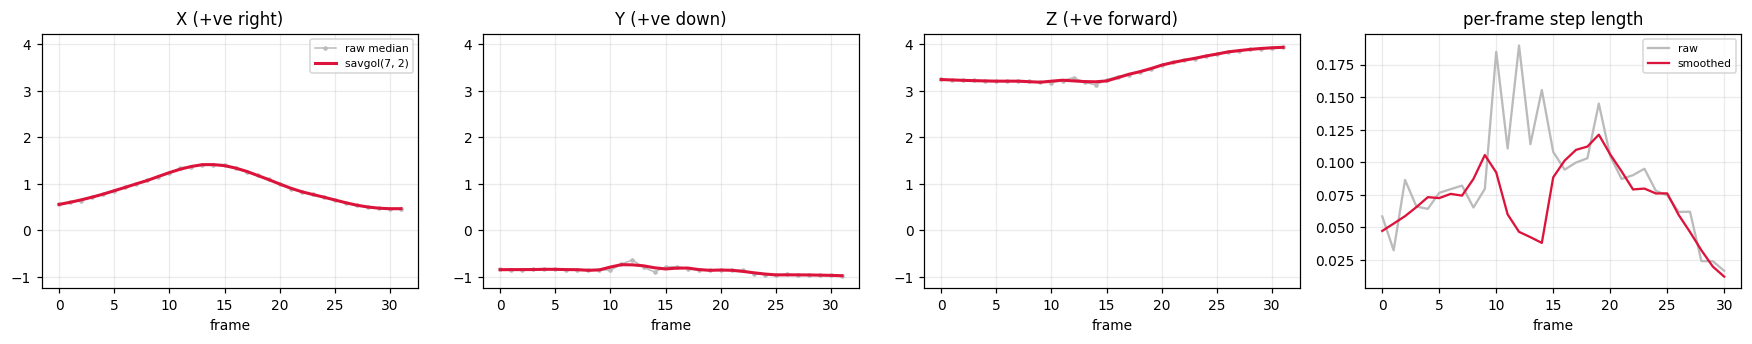

In [214]:
smoothed = smooth_trajectory(agg["ransac_median"])

fig, axes = plt.subplots(1, 4, figsize=(16, 3.2))
for ax, k in zip(axes, range(3)):
    ax.plot(agg["ransac_median"][:, k], lw=1.0, color="#bbbbbb", marker=".", ms=4, label="raw median")
    ax.plot(smoothed[:, k], lw=2.0, color="crimson", label="savgol(7, 2)")
    ax.set_xlabel("frame"); ax.set_title(AX[k])
    if k == 0: ax.legend(fontsize=7)
lock_axes(axes[:3])
step = np.linalg.norm(np.diff(agg["ransac_median"], axis=0), axis=1)
axes[3].plot(step, color="#bbbbbb", label="raw")
axes[3].plot(np.linalg.norm(np.diff(smoothed, axis=0), axis=1), color="crimson", label="smoothed")
axes[3].set_xlabel("frame"); axes[3].set_title("per-frame step length"); axes[3].legend(fontsize=7)
plt.tight_layout(); plt.show()

## Step 7 — post-processing: smoothing and axis filtering

Everything up to here reproduces the pipeline exactly. This step deliberately does *not* — it is
extra cleanup applied on top. Step 8 names the filtered subject and camera paths as the notebook's
finished trajectories, and every later trajectory-derived section consumes those finished paths.

Two operations, both applied to the subject trajectory and the camera path with the same code:

1. **Running mean over 5 frames.** A plain box average, and the smoother of record from here on:
   it is what feeds the axis filter and everything after it. Step 6's Savitzky–Golay is still
   *computed*, because the pipeline uses it and the step 8 verification compares against what the
   pipeline wrote — it just is not what this step builds on.
2. **Axis filtering.** If one axis carries far less motion than the busiest one, treat it as noise
   and flatten it to its median.

On "deterministic": the pipeline already is. `robust_rigid` is seeded with `seed=t`, so a rerun is
bit-identical — the step 8 verification below shows `0.000e+00` against the stored output, and that
is a rerun agreeing with itself. Nothing here adds determinism; what it adds is *stability*, which
is the different property of not wobbling frame to frame.

### On measuring an axis in centimetres

You can't, from these arrays. D4RT's units are arbitrary — the training loss normalises each clip
by its own mean depth — so the same physical 15 cm is a different number in every clip, and an
absolute cutoff would be strict on one and inert on the next. Two relative tests instead:

* **share of the busiest axis** — keep an axis when its span is at least `AXIS_KEEP_RATIO` of the
  largest axis span. This is the test as you described it: 15 cm against 2 m is a ratio of 0.075.
* **against the clip's own noise floor** — the scatter of the raw signal about the smoothed one is
  a direct estimate of the per-axis noise. An axis whose whole range is comparable to its own noise
  is not measuring motion, regardless of what the other axes do.

Both are printed, and `AXIS_RULE` picks which one decides. They do not always agree, and the
disagreement is the interesting part: an axis can be far above its own noise floor — real,
measured motion — and still be small next to the busiest axis. The ratio rule discards it anyway.
That is a modelling choice ("I only care about the dominant direction"), not a noise removal, and
it is worth being clear which one you are making. Watch the `span/noise` column when an axis gets
flattened: a large value there means you just threw away signal, not noise.

In [215]:
def running_mean(track, window=5):
    """Centred box average.  Gaps are interpolated for the filter then restored, and the window
    shrinks at the ends rather than padding -- no invented data outside the clip."""
    track = np.asarray(track, float)
    finite = np.isfinite(track).all(axis=1)
    if finite.sum() < 2:
        return track.copy()
    filled = track.copy()
    if not finite.all():
        i = np.arange(len(track))
        for a in range(3):
            filled[:, a] = np.interp(i, i[finite], track[finite, a])
    half, n = window // 2, len(filled)
    out = np.empty_like(filled)
    for t in range(n):
        out[t] = filled[max(0, t - half):min(n, t + half + 1)].mean(axis=0)
    out[~finite] = np.nan
    return out


def axis_spans(track):
    """Robust per-axis extent: the 5th-to-95th percentile range, so one bad frame cannot set it."""
    f = track[np.isfinite(track).all(axis=1)]
    if len(f) < 2:
        return np.zeros(3)
    return np.percentile(f, 95, axis=0) - np.percentile(f, 5, axis=0)


def axis_noise(raw, smooth):
    """Per-axis noise floor: the scatter of the raw signal about the smoothed one."""
    d = raw - smooth
    d = d[np.isfinite(d).all(axis=1)]
    return d.std(axis=0) if len(d) else np.zeros(3)


AXIS_KEEP_RATIO = 0.10      # "ratio" rule: keep an axis at >= 10% of the busiest axis's span
NOISE_FACTOR    = 2.0       # "noise" rule: keep an axis whose span exceeds 2x its own noise
AXIS_RULE       = "ratio"   # which of the two decides.  "ratio" is the rule as described;
                            # "noise" keeps anything measurably above the clip's noise floor.


def filter_axes(track, raw=None, ratio=AXIS_KEEP_RATIO, label=""):
    span = axis_spans(track)
    noise = axis_noise(raw, track) if raw is not None else np.full(3, np.nan)
    keep = (span >= ratio * span.max()) if AXIS_RULE == "ratio" else (span >= NOISE_FACTOR * noise)
    out = track.copy()
    for a in range(3):
        if not keep[a]:
            out[:, a] = np.nanmedian(track[:, a])     # flatten to its median, not to zero
    print(f"  {label}   (rule = {AXIS_RULE!r})")
    print(f"    {'axis':6s} {'span':>9s} {'share':>7s} {'noise':>9s} {'span/noise':>11s}   verdict")
    for a, nm in enumerate("XYZ"):
        snr = span[a] / noise[a] if noise[a] > 0 else np.inf
        flag = "" if keep[a] else "  <- flattened"
        weak = "  (span < 2x noise)" if np.isfinite(snr) and snr < NOISE_FACTOR else ""
        print(f"    {nm:6s} {span[a]:9.4f} {span[a]/span.max():7.2f} {noise[a]:9.4f} "
              f"{snr:11.1f}   {'keep' if keep[a] else 'noise'}{flag}{weak}")
    return out, span, keep

axis filtering
  subject   (rule = 'ratio')
    axis        span   share     noise  span/noise   verdict
    X         0.8882    1.00    0.0192        46.2   keep
    Y         0.1894    0.21    0.0396         4.8   keep
    Z         0.7103    0.80    0.0272        26.1   keep
  camera   (rule = 'ratio')
    axis        span   share     noise  span/noise   verdict
    X         0.9942    1.00    0.0214        46.4   keep
    Y         0.1436    0.14    0.0123        11.7   keep
    Z         0.2687    0.27    0.0096        28.0   keep


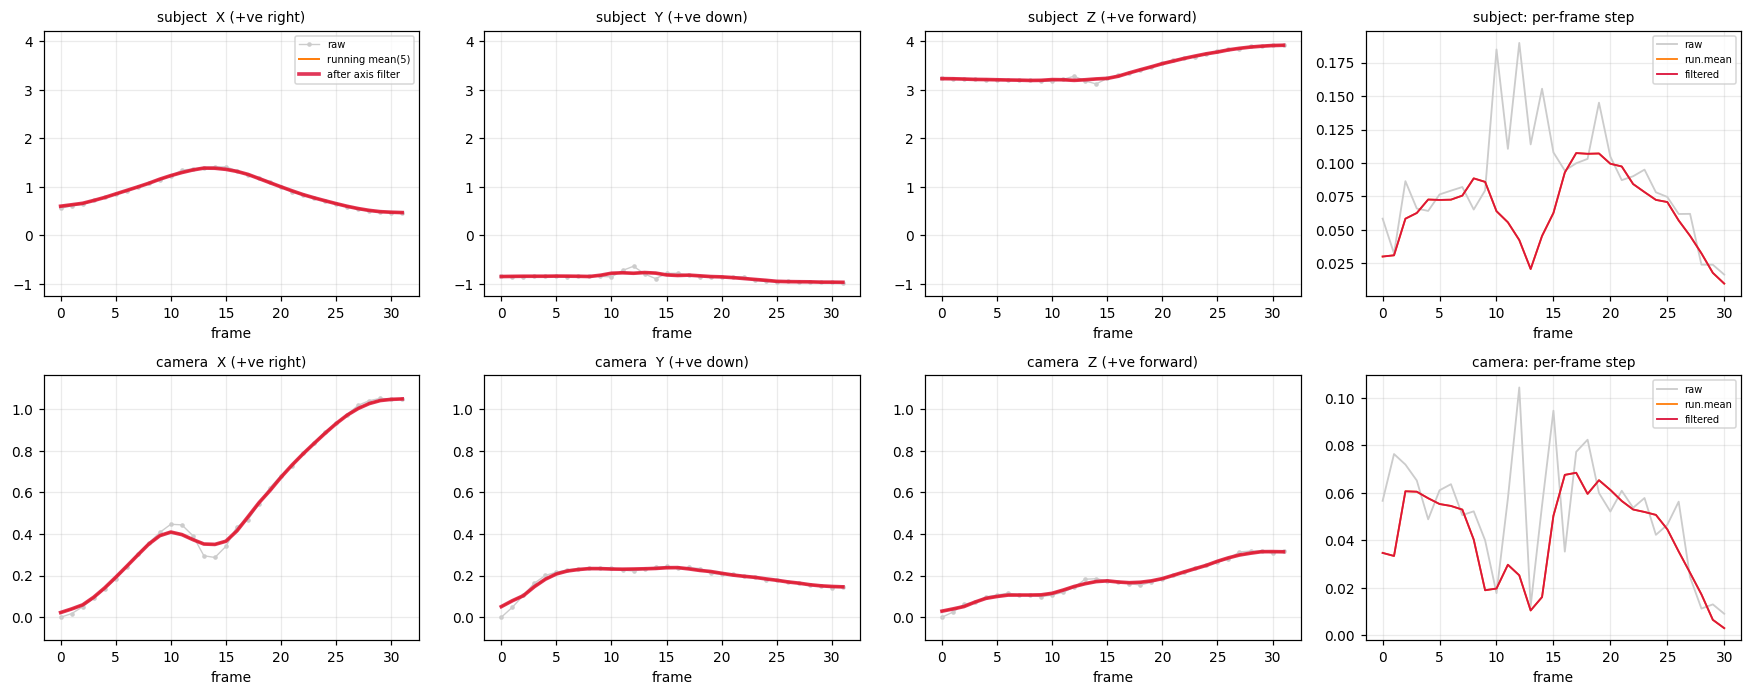


                 raw  run.mean  filtered   (path length)
subject       2.7130    2.0203    2.0203
camera        1.6095    1.2871    1.2871

Smoothing always shortens the path -- it flattens real turning points along with the
noise.  The axis filter shortens it further, by removing whole axes.

                 raw  run.mean   (displacement start->end)
subject       0.7077    0.7112    first-frame shift 0.0472
camera        1.1041    1.0706    first-frame shift 0.0630

Watch the first-frame shift.  A centred box average has no data before frame 0, so its
window is one-sided there and the endpoint is dragged toward the interior -- on a trajectory
that keeps moving one way, both ends get pulled in and the displacement shrinks.  If you
report displacement or start/end positions, this bias lands on the number you report.


In [216]:
# Subject and camera, through the same two operations.
subj_raw    = agg["ransac_median"]
subj_rm     = running_mean(subj_raw, window=5)
cam_rm      = running_mean(cam_track, window=5)

print("axis filtering")
subj_filt, subj_span, subj_keep = filter_axes(subj_rm, raw=subj_raw, label="subject")
cam_filt,  cam_span,  cam_keep  = filter_axes(cam_rm,  raw=cam_track, label="camera")

fig, axes = plt.subplots(2, 4, figsize=(16, 6.4))
for r, (rawt, savt, rmt, filt, nm) in enumerate([
        (subj_raw,  smoothed,   subj_rm, subj_filt, "subject"),
        (cam_track, cam_smooth, cam_rm,  cam_filt,  "camera")]):
    for k in range(3):
        ax = axes[r, k]
        ax.plot(rawt[:, k], lw=0.9, color="#cccccc", marker=".", ms=4, label="raw")
        ax.plot(rmt[:, k],  lw=1.3, color="#ff7f0e", label="running mean(5)")
        ax.plot(filt[:, k], lw=2.4, color="crimson", alpha=0.85, label="after axis filter")
        ax.set_title(f"{nm}  {AX[k]}", fontsize=9); ax.set_xlabel("frame")
        if r == 0 and k == 0: ax.legend(fontsize=6.5)
    lock_axes(axes[r, :3])                # within the row: subject and camera differ ~100x in
    ax = axes[r, 3]                       # magnitude, so locking across rows would flatten one
    for t_, c_, l_ in [(rawt, "#cccccc", "raw"),
                       (rmt, "#ff7f0e", "run.mean"), (filt, "crimson", "filtered")]:
        ax.plot(np.linalg.norm(np.diff(t_, axis=0), axis=1), color=c_, lw=1.2, label=l_)
    ax.set_title(f"{nm}: per-frame step", fontsize=9); ax.set_xlabel("frame"); ax.legend(fontsize=6.5)
plt.tight_layout(); plt.show()

def plen(t_):
    d = np.diff(t_, axis=0); d = d[np.isfinite(d).all(axis=1)]
    return float(np.linalg.norm(d, axis=1).sum())

print(f"\n{'':10s} {'raw':>9s} {'run.mean':>9s} {'filtered':>9s}   (path length)")
for nm, a, c_, d_ in [("subject", subj_raw, subj_rm, subj_filt),
                      ("camera",  cam_track, cam_rm, cam_filt)]:
    print(f"{nm:10s} {plen(a):9.4f} {plen(c_):9.4f} {plen(d_):9.4f}")
print("\nSmoothing always shortens the path -- it flattens real turning points along with the")
print("noise.  The axis filter shortens it further, by removing whole axes.")

def ends(t_):
    f = t_[np.isfinite(t_).all(axis=1)]
    return f[0], f[-1], float(np.linalg.norm(f[-1] - f[0]))

print(f"\n{'':10s} {'raw':>9s} {'run.mean':>9s}   (displacement start->end)")
for nm, a, c_ in [("subject", subj_raw, subj_rm), ("camera", cam_track, cam_rm)]:
    print(f"{nm:10s} {ends(a)[2]:9.4f} {ends(c_)[2]:9.4f}"
          f"    first-frame shift {np.linalg.norm(ends(c_)[0]-ends(a)[0]):.4f}")
print("\nWatch the first-frame shift.  A centred box average has no data before frame 0, so its")
print("window is one-sided there and the endpoint is dragged toward the interior -- on a trajectory")
print("that keeps moving one way, both ends get pulled in and the displacement shrinks.  If you")
print("report displacement or start/end positions, this bias lands on the number you report.")

### Is an axis-aligned test the right test?

Flattening an axis only makes sense if the motion actually runs along the coordinate axes. The
camera frame's X/Y/Z were fixed by where the camera happened to be pointing at `t=0`; the subject
did not agree to walk along any of them. If someone moves diagonally — say 45° between X and Z —
then both axes carry a large share, neither gets flattened, and the test has done nothing even
though the motion is genuinely one-dimensional.

The check below is PCA on the trajectory. If the first component holds nearly all the variance the
motion *is* essentially 1-D, and the listed angles say whether that direction is close enough to a
coordinate axis for the per-axis test to be the right tool.

In [217]:
for nm, t_ in [("subject", subj_rm), ("camera", cam_rm)]:
    f = t_[np.isfinite(t_).all(axis=1)]
    if len(f) < 3:
        print(f"{nm}: too few frames"); continue
    u, s, vt = np.linalg.svd(f - f.mean(axis=0), full_matrices=False)
    var = s ** 2 / (s ** 2).sum()
    ang = np.degrees(np.arccos(np.clip(np.abs(vt[0]), 0, 1)))     # angle to each coordinate axis
    print(f"{nm:8s} variance along PC1/PC2/PC3 = {var[0]:.3f} / {var[1]:.3f} / {var[2]:.3f}")
    print(f"{'':8s} PC1 direction {np.round(vt[0], 3)}   "
          f"angle to X/Y/Z = {ang[0]:5.1f} / {ang[1]:5.1f} / {ang[2]:5.1f} deg")
    near = "XYZ"[int(np.argmin(ang))]
    print(f"{'':8s} -> dominant direction is {ang.min():.1f} deg off the {near} axis; "
          f"per-axis filtering is {'appropriate' if ang.min() < 25 else 'the WRONG tool here'}\n")

subject  variance along PC1/PC2/PC3 = 0.838 / 0.161 / 0.001
         PC1 direction [ 0.749  0.157 -0.644]   angle to X/Y/Z =  41.5 /  80.9 /  49.9 deg
         -> dominant direction is 41.5 deg off the X axis; per-axis filtering is the WRONG tool here

camera   variance along PC1/PC2/PC3 = 0.978 / 0.019 / 0.003
         PC1 direction [0.97  0.001 0.242]   angle to X/Y/Z =  14.0 /  90.0 /  76.0 deg
         -> dominant direction is 14.0 deg off the X axis; per-axis filtering is appropriate



## Step 8 — the finished trajectory

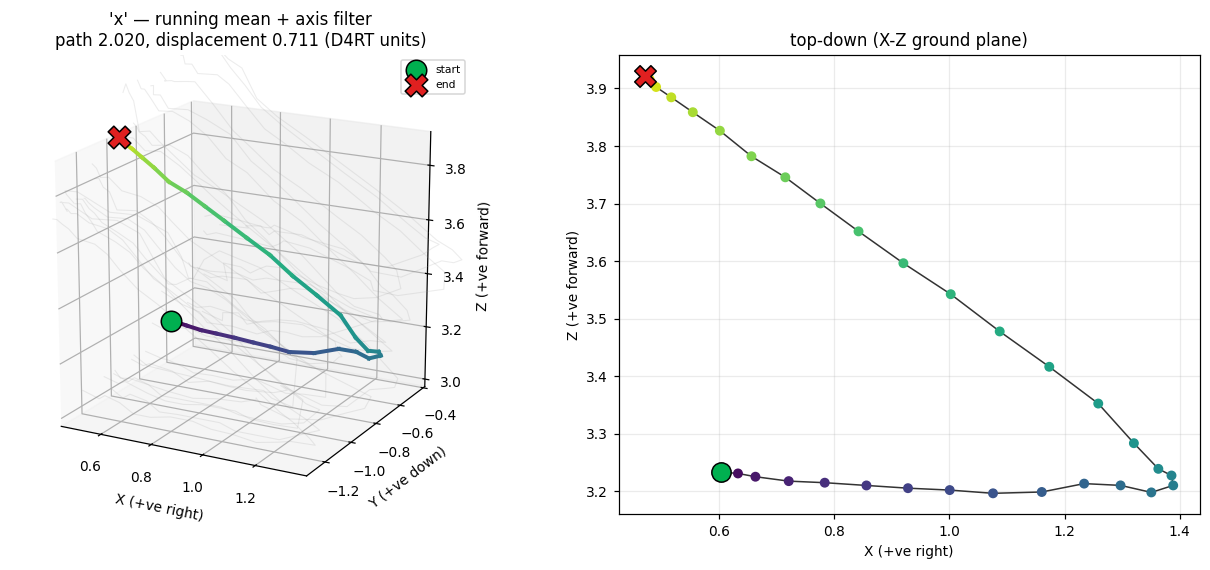

In [218]:
# The finished paths are Step 7's running-mean trajectories after axis filtering.
finished_subject = subj_filt
finished_camera = cam_filt
finite = np.isfinite(finished_subject).all(axis=1)
idx = np.flatnonzero(finite)
finished_path_len = float(np.linalg.norm(np.diff(finished_subject[finite], axis=0), axis=1).sum())
finished_displacement = float(np.linalg.norm(finished_subject[finite][-1] - finished_subject[finite][0]))

fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1, 2, 1, projection="3d")
for p in range(P):                                  # the spread the aggregate summarises
    if not keep[p]: continue
    ok = np.isfinite(masked[p]).all(axis=1)
    if ok.sum() > 1: ax.plot(*masked[p, ok].T, color="#999999", alpha=0.18, lw=0.7)
cm = plt.get_cmap("viridis")
for a, b in zip(idx[:-1], idx[1:]):
    ax.plot(*finished_subject[[a, b]].T, color=cm(a / max(T - 1, 1)), lw=2.6)
ax.scatter(*finished_subject[idx[0]],  s=180, c="#00b050", edgecolors="black", zorder=6, label="start")
ax.scatter(*finished_subject[idx[-1]], s=220, c="#e02020", marker="X", edgecolors="black", zorder=6, label="end")
label_3d(ax)
ax.set_title(f"{summary['subject']!r} — running mean + axis filter\n"
             f"path {finished_path_len:.3f}, displacement {finished_displacement:.3f} (D4RT units)")
ax.view_init(elev=18, azim=-62); ax.legend(fontsize=7)
equalise_3d(ax, finished_subject[finite])

ax = fig.add_subplot(1, 2, 2)                        # top-down: the readable view of "where it went"
ax.plot(finished_subject[finite, 0], finished_subject[finite, 2], color="#333333", lw=1.0)
ax.scatter(finished_subject[finite, 0], finished_subject[finite, 2], c=idx, cmap="viridis", s=30, zorder=3)
ax.scatter(*finished_subject[idx[0]][[0, 2]],  s=160, c="#00b050", edgecolors="black", zorder=4)
ax.scatter(*finished_subject[idx[-1]][[0, 2]], s=200, c="#e02020", marker="X", edgecolors="black", zorder=4)
ax.set_xlabel(AX[0]); ax.set_ylabel(AX[2]); ax.set_title("top-down (X-Z ground plane)")
ax.set_aspect("equal")
plt.tight_layout(); plt.show()

### Does the rebuild match the pipeline?

Step 8 intentionally adds running-mean smoothing and axis filtering beyond the pipeline. This check
therefore verifies the notebook's pre-Step-7 reconstruction (`smoothed`, rotations, translations,
and related arrays) against `analysis/trajectory.npz` and `analysis/camera_poses.npz`. They should
agree to floating point. The Step 8 finished paths are expected to differ because they include the
additional post-processing.

In [219]:
ref_traj = np.load(VD / "analysis" / "trajectory.npz")
ref_cam  = np.load(VD / "analysis" / "camera_poses.npz")

def diff(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    both_nan = np.isnan(a) & np.isnan(b)
    d = np.abs(np.where(both_nan, 0.0, a - b))
    return float(np.nanmax(d)) if d.size else 0.0

checks = [("valid",           valid,                 ref_traj["valid"]),
          ("keep",            keep,                  ref_traj["keep"]),
          ("mean",            agg["mean"],           ref_traj["mean"]),
          ("median",          agg["median"],         ref_traj["median"]),
          ("ransac_median",   agg["ransac_median"],  ref_traj["ransac_median"]),
          ("smoothed",        smoothed,              ref_traj["smoothed"]),
          ("n_inliers",       agg["n_inliers"],      ref_traj["n_inliers"]),
          ("camera rotation", rot,                   ref_cam["rotation"]),
          ("camera transl.",  trans,                 ref_cam["translation"]),
          ("camera rmse",     rmse,                  ref_cam["rmse"]),
          ("camera inliers",  ninl,                  ref_cam["inlier_counts"])]

print(f"{'array':18s} {'max |difference|':>18s}")
for name, mine, theirs in checks:
    print(f"{name:18s} {diff(mine, theirs):18.3e}   {'OK' if diff(mine, theirs) < 1e-9 else 'MISMATCH'}")

rebuilt_finite = np.isfinite(smoothed).all(axis=1)
rebuilt_path_len = float(np.linalg.norm(np.diff(smoothed[rebuilt_finite], axis=0), axis=1).sum())
print(f"\npipeline summary says: kept {summary['tracks_kept']}/{summary['tracks_total']} tracks, "
      f"path length {summary['trajectory_path_length']:.4f}")
print(f"notebook rebuild says: kept {keep.sum()}/{P} tracks, path length {rebuilt_path_len:.4f}")
print(f"Step 8 post-processed subject path length: {finished_path_len:.4f}")
if summary["warnings"]:
    print("\nwarnings recorded by the pipeline:")
    for w in summary["warnings"]: print("  -", w)

array                max |difference|
valid                       0.000e+00   OK
keep                        0.000e+00   OK
mean                        0.000e+00   OK
median                      0.000e+00   OK
ransac_median               0.000e+00   OK
smoothed                    0.000e+00   OK
n_inliers                   0.000e+00   OK
camera rotation             0.000e+00   OK
camera transl.              0.000e+00   OK
camera rmse                 0.000e+00   OK
camera inliers              0.000e+00   OK

pipeline summary says: kept 18/20 tracks, path length 2.2046
notebook rebuild says: kept 18/20 tracks, path length 2.2046
Step 8 post-processed subject path length: 2.0203


## Step 9 — how far is the subject from the camera?

Everything needed for this already exists, and it exists in a *comparable* form, which is the part
worth pausing on. The subject trajectory was queried with `t_cam=0` fixed, so all 32 positions are
expressed in frame-0 camera coordinates. Step 3 recovered each camera's pose in those same frame-0
coordinates. Two different queries, one shared frame — so they can simply be subtracted:

$$\mathbf{r}(t) = \mathbf{p}_{\text{subject}}(t) - \mathbf{c}_{\text{camera}}(t)$$

Three views of that vector, because they answer different questions:

* **‖r(t)‖** — the total separation. Is the subject approaching or receding?
* **per axis, two ways.** The *absolute* panel keeps the real values, so the three components
  together say where the subject sits — on this clip Z is an order of magnitude larger than X and
  Y, meaning the subject is almost straight down the optical axis. The *change* panel plots the
  identical curves with each one's frame-0 value subtracted, so all three start at zero and you
  read the movement directly instead of squinting at a small wiggle riding on a large offset. Same
  data, one constant apart: absolute answers *where*, delta answers *how much it moved*.
* **the two paths drawn together, one coordinate at a time**, each plotted as *change from the
  first frame* — the subject's line and the camera's line both start at zero, and the shaded band
  between them is how much the separation has changed since frame 0. Plotting the raw positions
  instead would put a constant offset of several units in the Z panel and flatten everything
  happening inside it; the starting gap is printed in each title so nothing is lost. Which line
  moves tells you which of the two is responsible.

Two things to keep in mind. These are D4RT units, not metres — the training loss normalises by mean
depth, so no absolute scale is recoverable. This section deliberately builds on Step 8 and therefore
uses the **running-mean, axis-filtered** subject and camera paths. Any axis flattened in Step 7 is
treated as intentionally suppressed motion in every result below.

sanity: at t=0 the camera sits at the origin, so the separation must equal |subject(0)|
        |r(0)| = 3.3952   |subject(0)| = 3.3952   difference 0.00e+00



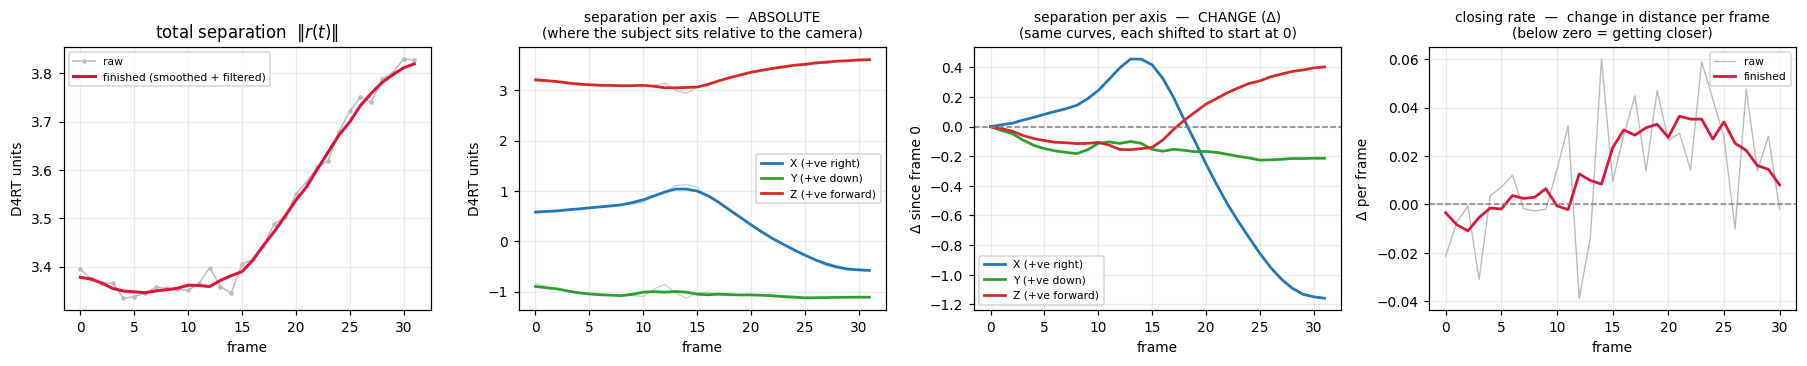

separation   start  3.3779   end  3.8191   net +0.4412  (+13.1%)
             min    3.3462 (frame 6)   max  3.8191 (frame 31)
             range  0.4729   = 14.0% of the starting distance

how much of the change is the subject moving vs the camera moving:
  subject path  2.0203   camera path  1.2871


In [220]:
# Frame-0 coordinates throughout; Step 8 finished paths, with the raw pair for comparison.
sep_raw    = agg["ransac_median"] - cam_track
sep_smooth = finished_subject - finished_camera
dist_raw, dist_smooth = np.linalg.norm(sep_raw, axis=1), np.linalg.norm(sep_smooth, axis=1)

print(f"sanity: at t=0 the camera sits at the origin, so the separation must equal |subject(0)|")
print(f"        |r(0)| = {dist_raw[0]:.4f}   |subject(0)| = {np.linalg.norm(agg['ransac_median'][0]):.4f}"
      f"   difference {abs(dist_raw[0] - np.linalg.norm(agg['ransac_median'][0])):.2e}\n")

fig, axes = plt.subplots(1, 4, figsize=(16.5, 3.4))

ax = axes[0]
ax.plot(dist_raw, lw=1.0, color="#bbbbbb", marker=".", ms=4, label="raw")
ax.plot(dist_smooth, lw=2.0, color="crimson", label="finished (smoothed + filtered)")
ax.set_xlabel("frame"); ax.set_ylabel("D4RT units")
ax.set_title(r"total separation  $\|r(t)\|$"); ax.legend(fontsize=7)

ax = axes[1]
for k, (nm, col) in enumerate(zip(AX, ["#1f77b4", "#2ca02c", "#d62728"])):
    ax.plot(sep_raw[:, k], lw=0.8, color=col, alpha=0.35)
    ax.plot(sep_smooth[:, k], lw=1.8, color=col, label=nm)
ax.set_xlabel("frame"); ax.set_ylabel("D4RT units")
ax.set_title("separation per axis  —  ABSOLUTE\n(where the subject sits relative to the camera)", fontsize=9)
ax.legend(fontsize=7)

ax = axes[2]
for k, (nm, col) in enumerate(zip(AX, ["#1f77b4", "#2ca02c", "#d62728"])):
    ax.plot(sep_smooth[:, k] - sep_smooth[0, k], lw=1.8, color=col, label=nm)
ax.axhline(0, ls="--", lw=1, color="grey")
ax.set_xlabel("frame"); ax.set_ylabel("Δ since frame 0")
ax.set_title("separation per axis  —  CHANGE (Δ)\n(same curves, each shifted to start at 0)", fontsize=9)
ax.legend(fontsize=7)

ax = axes[3]
ax.plot(np.diff(dist_raw), lw=0.9, color="#bbbbbb", label="raw")
ax.plot(np.diff(dist_smooth), lw=1.8, color="crimson", label="finished")
ax.axhline(0, ls="--", lw=1, color="grey")
ax.set_xlabel("frame"); ax.set_ylabel("Δ per frame")
ax.set_title("closing rate  —  change in distance per frame\n(below zero = getting closer)", fontsize=9)
ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

d0, d1 = dist_smooth[0], dist_smooth[-1]
print(f"separation   start {d0:7.4f}   end {d1:7.4f}   net {d1 - d0:+7.4f}  ({100*(d1/d0 - 1):+.1f}%)")
print(f"             min   {dist_smooth.min():7.4f} (frame {int(np.argmin(dist_smooth))})"
      f"   max {dist_smooth.max():7.4f} (frame {int(np.argmax(dist_smooth))})")
print(f"             range {dist_smooth.max() - dist_smooth.min():7.4f}"
      f"   = {(dist_smooth.max() - dist_smooth.min()) / max(d0, 1e-9) * 100:.1f}% of the starting distance")
print(f"\nhow much of the change is the subject moving vs the camera moving:")
print(f"  subject path {np.linalg.norm(np.diff(finished_subject, axis=0), axis=1).sum():7.4f}"
      f"   camera path {np.linalg.norm(np.diff(finished_camera, axis=0), axis=1).sum():7.4f}")

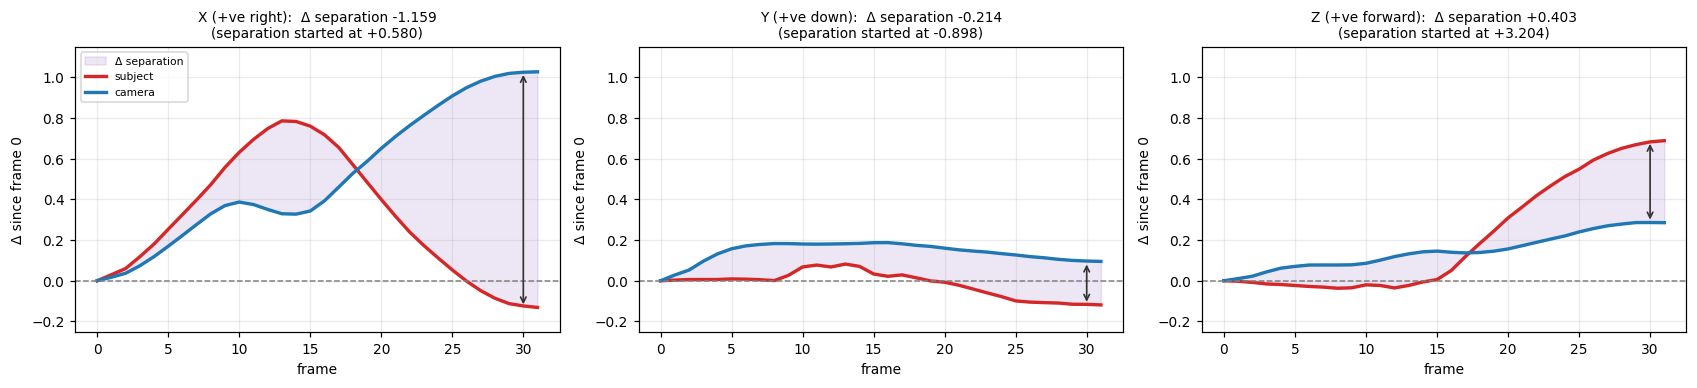

Both curves start at zero, so the shaded band is the CHANGE in separation, not the
separation itself -- the constant offset (printed in each title) has been subtracted out.
Which line moves still tells you who caused the change.

axis     gap t=0  gap t=end    change    subject moved  camera moved   who closed it
X         0.5801    -0.5786   -1.1587          -0.1313        1.0274   camera
Y        -0.8983    -1.1122   -0.2139          -0.1188        0.0950   both
Z         3.2042     3.6075    0.4033           0.6888        0.2855   both


In [221]:
# One coordinate at a time, as CHANGE from the first frame.  Plotting absolute positions puts
# a constant ~5-unit offset in the Z panel that swamps everything moving inside it; subtracting
# each track's own starting value removes the offset and keeps the shape.
def rel(track):
    """Track minus its own first finite frame, so every curve starts at zero."""
    f = np.flatnonzero(np.isfinite(track).all(axis=1))
    return track - track[f[0]] if len(f) else track.copy()

subj_rel, cam_rel = rel(finished_subject), rel(finished_camera)
frames = np.arange(T)

fig, axes = plt.subplots(1, 3, figsize=(15.5, 3.6))
for k, nm in enumerate(AX):
    ax = axes[k]
    ax.fill_between(frames, cam_rel[:, k], subj_rel[:, k], color="#9467bd", alpha=0.16,
                    label="Δ separation")
    ax.plot(frames, subj_rel[:, k], lw=2.2, color="#d62728", label="subject")
    ax.plot(frames, cam_rel[:, k],  lw=2.2, color="#1f77b4", label="camera")
    ax.axhline(0, ls="--", lw=1, color="grey")
    dg = (subj_rel[:, k] - cam_rel[:, k])
    ax.annotate("", xy=(T - 2, subj_rel[-1, k]), xytext=(T - 2, cam_rel[-1, k]),
                arrowprops=dict(arrowstyle="<->", color="#333333", lw=1.1))
    ax.set_xlabel("frame"); ax.set_ylabel("Δ since frame 0")
    ax.set_title(f"{nm}:  Δ separation {dg[-1]:+.3f}"
                 f"\n(separation started at {sep_smooth[0, k]:+.3f})", fontsize=9)
    if k == 0: ax.legend(fontsize=7, loc="best")
lock_axes(axes)                           # one scale across X, Y and Z
plt.tight_layout(); plt.show()

print("Both curves start at zero, so the shaded band is the CHANGE in separation, not the")
print("separation itself -- the constant offset (printed in each title) has been subtracted out.")
print("Which line moves still tells you who caused the change.\n")
print(f"{'axis':6s} {'gap t=0':>9s} {'gap t=end':>10s} {'change':>9s}   "
      f"{'subject moved':>14s} {'camera moved':>13s}   who closed it")
for k, nm in enumerate("XYZ"):
    ds, dc = subj_rel[-1, k], cam_rel[-1, k]
    who = "subject" if abs(ds) > 3 * abs(dc) else ("camera" if abs(dc) > 3 * abs(ds) else "both")
    print(f"{nm:6s} {sep_smooth[0, k]:9.4f} {sep_smooth[-1, k]:10.4f} "
          f"{sep_smooth[-1, k]-sep_smooth[0, k]:9.4f}   {ds:14.4f} {dc:13.4f}   {who}")

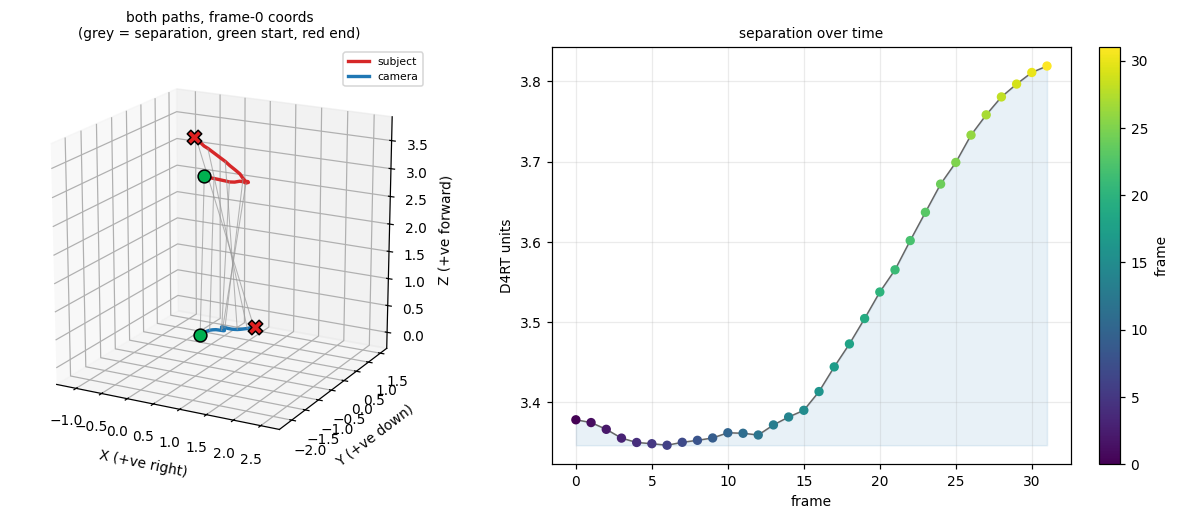

In [222]:
# The two paths in one frame, with the separation drawn at intervals.
fig = plt.figure(figsize=(11.5, 4.8))

ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.plot(*finished_subject.T, color="#d62728", lw=2.2, label="subject")
ax.plot(*finished_camera.T,  color="#1f77b4", lw=2.2, label="camera")
for t in range(0, T, max(1, T // 8)):
    ax.plot(*np.array([finished_camera[t], finished_subject[t]]).T, color="#999999", lw=0.7, alpha=0.7)
ax.scatter(*finished_subject[0],  s=70, c="#00b050", edgecolors="black", zorder=6)
ax.scatter(*finished_subject[-1], s=90, c="#e02020", marker="X", edgecolors="black", zorder=6)
ax.scatter(*finished_camera[0],   s=70, c="#00b050", edgecolors="black", zorder=6)
ax.scatter(*finished_camera[-1],  s=90, c="#e02020", marker="X", edgecolors="black", zorder=6)
label_3d(ax)
ax.set_title("both paths, frame-0 coords\n(grey = separation, green start, red end)", fontsize=9)
ax.view_init(elev=18, azim=-62); ax.legend(fontsize=7)
equalise_3d(ax, np.vstack([finished_subject, finished_camera]))

ax = fig.add_subplot(1, 2, 2)
sc = ax.scatter(np.arange(T), dist_smooth, c=np.arange(T), cmap="viridis", s=26, zorder=3)
ax.plot(dist_smooth, color="#666666", lw=1.0, zorder=2)
ax.fill_between(np.arange(T), dist_smooth.min(), dist_smooth, color="#1f77b4", alpha=0.10)
ax.set_xlabel("frame"); ax.set_ylabel("D4RT units"); ax.set_title("separation over time", fontsize=9)
fig.colorbar(sc, ax=ax, label="frame", fraction=0.04)
plt.tight_layout(); plt.show()

## Give trajectory in natural language

Turn the finished splines into short, quantitative instructions an agent can consume. Each path is
sampled at 11 equally spaced times, producing **10 uniform-duration segments**. Each segment's
displacement is snapped by angle to the closest of the **26 non-zero directions in a 3×3×3 Moore
neighbourhood**; its magnitude remains the measured Euclidean distance in D4RT units.

The words follow an OpenCV-style local convention: **+x right, +y down, +z forward**. Thus negative
y is reported as **up**, not down. Distances are scale-relative D4RT units, not metres.

Two things this section reports that the raw spline does not, and both exist because DSI-Bench asks
for them directly:

**Orientation travels with the translation.** Every segment carries how far the body *turned* during
it, not just where it went. A camera moving left with no pan is sliding past the scene; the same
translation with a compensating rightward pan is orbiting it, and DSI-Bench offers both as options of
one question. Likewise "moving forward and turning left" is a common ground-truth answer for a
subject. The angles come from arrays already on disk — `camera_poses.npz:rotation` for the observer,
`trajectory.npz:forward_cam0` for the subject — so this is a reporting change, not new estimation.

**Nothing is called motion until it clears a noise floor.** On a static camera the per-segment steps
are ~0.001 units and their directions are essentially random; read literally they describe a
wandering camera. The floor is referenced to a scale the track does not itself set — the scene scale
for the camera, the subject's own extent for the subject — because a floor derived from the track's
own extent shrinks with the signal and can never call anything stationary. "Basically unchange" is
one of the commonest ground-truth options in the benchmark, so this distinction decides real answers.

Subject-frame output stays deliberately unavailable when Orient-Anything did not resolve a unique
front: silently substituting camera directions would answer a different question.

In [223]:
# Both deployment frames are emitted below; only the shared segment count is configurable.
N_LANGUAGE_SEGMENTS = 10
UP_IN_CAMERA = np.array([0.0, -1.0, 0.0])     # world up, in a frame where +y is DOWN

# Motion below these fractions of the relevant scale is not reported as motion.  The subject is
# judged against its own extent, the camera against the scene's -- see the note above on why a
# floor taken from the track's own extent can never call anything stationary.
SUBJECT_FLOOR_RATIO = 0.10
CAMERA_FLOOR_RATIO  = 0.01

_LATTICE = np.array([(x, y, z) for x in (-1, 0, 1) for y in (-1, 0, 1) for z in (-1, 0, 1)
                     if (x, y, z) != (0, 0, 0)], dtype=float)
_UNIT_LATTICE = _LATTICE / np.linalg.norm(_LATTICE, axis=1, keepdims=True)


def direction_name(step):
    """Snap a displacement to the closest of the 26 Moore-neighbour directions."""
    length = float(np.linalg.norm(step))
    if not np.isfinite(length) or length <= 1e-12:
        return "stationary"
    sx, sy, sz = _LATTICE[np.argmax(_UNIT_LATTICE @ (np.asarray(step, float) / length))].astype(int)
    words = []
    if sy: words.append("down" if sy > 0 else "up")
    if sx: words.append("right" if sx > 0 else "left")
    if sz: words.append("forward" if sz > 0 else "backward")
    return "-".join(words)


def uniform_time_segments(track, n_segments=10):
    """Interpolate a finite (T,3) path at n+1 uniformly spaced frame times."""
    track = np.asarray(track, float)
    finite = np.isfinite(track).all(axis=1)
    frames = np.flatnonzero(finite).astype(float)
    if len(frames) < 2:
        raise ValueError("trajectory needs at least two finite samples")
    sample_frames = np.linspace(frames[0], frames[-1], n_segments + 1)
    samples = np.column_stack([np.interp(sample_frames, frames, track[finite, a]) for a in range(3)])
    return sample_frames, samples


def unit(v):
    n = float(np.linalg.norm(v))
    return None if (not np.isfinite(n) or n <= 1e-12) else np.asarray(v, float) / n


def wrap180(a, b):
    """a - b, folded into (-180, 180]."""
    return ((float(a) - float(b) + 180.0) % 360.0) - 180.0


def unwrap_deg(angles):
    """Unwrap, keeping NaN gaps LOCAL -- np.unwrap would spread one NaN across the whole tail."""
    angles = np.asarray(angles, float)
    out = np.full_like(angles, np.nan)
    ok = np.isfinite(angles)
    if ok.any():
        out[ok] = np.degrees(np.unwrap(np.radians(angles[ok])))
    return out


def camera_pose_angles(rotation):
    """Per-frame pan / tilt / roll of the camera, relative to frame 0.

    rot[t] maps directions in camera-t into camera-0, so its columns ARE camera-t's axes seen from
    the start: column 2 is where it looks, column 0 is its right.  Reading the angles off those two
    axes avoids picking an Euler convention and avoids gimbal degeneracies near the poles.

        pan  = atan2(f_x, f_z)   + is a turn to the camera's own right
        tilt = -asin(f_y)        + is upward, because +y points DOWN
        roll = signed angle from the level right axis to the actual one, about the view direction
    """
    rotation = np.asarray(rotation, float)
    T_ = rotation.shape[0]
    pan  = np.full(T_, np.nan); tilt = np.full(T_, np.nan); roll = np.full(T_, np.nan)
    for t in range(T_):
        R_ = rotation[t]
        if not np.isfinite(R_).all():
            continue
        f, r = unit(R_[:, 2]), unit(R_[:, 0])
        if f is None or r is None:
            continue
        pan[t]  = np.degrees(np.arctan2(f[0], f[2]))
        tilt[t] = np.degrees(-np.arcsin(np.clip(f[1], -1, 1)))
        level = unit(np.cross(f, UP_IN_CAMERA))
        if level is None:                      # looking straight up/down: "level" is undefined
            continue
        roll[t] = np.degrees(np.arctan2(float(np.cross(level, r) @ f), float(level @ r)))
    return {"pan_deg": pan, "tilt_deg": tilt, "roll_deg": roll}


def subject_heading_angles(forward_cam0, orientation_usable):
    """Per-frame subject heading, relative to its FIRST resolved facing.

    forward_cam0 is already rotated into the frame-0 camera, so a change here is the subject
    turning rather than the camera moving around it.  alpha != 1 frames stay NaN: a symmetric or
    unresolvable object has no meaningful facing, and reporting one is how a plausible-looking
    wrong answer gets made.
    """
    forward = np.asarray(forward_cam0, float)
    usable  = np.asarray(orientation_usable, bool)
    T_ = forward.shape[0]
    heading = np.full(T_, np.nan)
    for t in range(T_):
        if t >= len(usable) or not usable[t]:
            continue
        f = unit(forward[t])
        if f is not None:
            heading[t] = np.degrees(np.arctan2(f[0], f[2]))
    ok = np.flatnonzero(np.isfinite(heading))
    if len(ok):
        ref = heading[ok[0]]
        heading = np.array([wrap180(v, ref) if np.isfinite(v) else np.nan for v in heading])
    return {"heading_deg": heading}


def angle_noise_deg(angles, floor=2.0):
    """MAD scatter of an angle track about its own running mean, with a floor.

    2 degrees because pan is recovered indirectly, through a RANSAC rigid fit on a 144-point grid.
    """
    a = unwrap_deg(angles)
    sm = np.full_like(a, np.nan)
    for t in range(len(a)):
        w = a[max(0, t - 2):t + 3]
        w = w[np.isfinite(w)]
        if w.size: sm[t] = w.mean()
    res = (a - sm)[np.isfinite(a - sm)]
    if res.size == 0:
        return float(floor)
    return float(max(2.0 * 1.4826 * np.median(np.abs(res - np.median(res))), floor))


def displacement_noise(raw, smooth, floor):
    """How far a path must move before it counts.  `floor` comes from an INDEPENDENT scale."""
    res = np.linalg.norm(np.asarray(raw, float) - np.asarray(smooth, float), axis=1)
    res = res[np.isfinite(res)]
    if res.size == 0:
        return float(max(floor, 1e-6))
    return float(max(2.0 * 1.4826 * np.median(np.abs(res - np.median(res))), floor, 1e-6))


def segment_report(track, angle_tracks, basis=None, n_segments=N_LANGUAGE_SEGMENTS, noise=0.0):
    """Ten uniform-duration segments of translation, each carrying its rotation.

    The angle tracks are sampled at the SAME frame times as the positions, so a segment's direction
    word and its angle delta describe one interval rather than two loosely related ones.
    """
    sample_frames, points = uniform_time_segments(track, n_segments)
    points = points - points[0]
    if basis is not None:
        points = points @ basis

    sampled = {}
    for name, values in angle_tracks.items():
        u = unwrap_deg(values)
        ok = np.isfinite(u)
        if ok.sum() < 2:
            sampled[name] = np.full(len(sample_frames), np.nan); continue
        fr = np.flatnonzero(ok).astype(float)
        s = np.interp(sample_frames, fr, u[ok])
        s[(sample_frames < fr[0]) | (sample_frames > fr[-1])] = np.nan   # never extrapolate
        sampled[name] = s

    steps = np.diff(points, axis=0)
    dist  = np.linalg.norm(steps, axis=1)
    segments = []
    for i in range(n_segments):
        row = {"segment": i + 1, "frame_start": float(sample_frames[i]),
               "frame_end": float(sample_frames[i + 1]), "direction": direction_name(steps[i]),
               "distance": float(dist[i]), "above_noise": bool(dist[i] > noise)}
        for name, v in sampled.items():
            d = v[i + 1] - v[i]
            row[f"{name}_delta"] = None if not np.isfinite(d) else float(d)
        segments.append(row)

    runs = []
    for s in segments:
        if runs and runs[-1]["direction"] == s["direction"]:
            runs[-1]["count"] += 1; runs[-1]["distance"] += s["distance"]
        else:
            runs.append({"direction": s["direction"], "count": 1, "distance": s["distance"]})

    totals, spans = {}, {}
    for name, v in sampled.items():
        ok = np.isfinite(v)
        totals[name] = float(v[ok][-1] - v[ok][0]) if ok.sum() >= 2 else None
        cov = sample_frames[ok]
        spans[name] = [float(cov[0]), float(cov[-1])] if len(cov) >= 2 else None

    net = float(np.linalg.norm(points[-1] - points[0]))
    return {"sample_frames": sample_frames, "segments": segments, "runs": runs,
            "angle_totals": totals, "angle_spans": spans,
            "angle_noise_deg": {k: angle_noise_deg(v) for k, v in angle_tracks.items()},
            "noise_floor": float(noise), "total_distance": float(np.nansum(dist)),
            "net_displacement": net, "net_above_noise": bool(net > noise),
            "full_span": [float(sample_frames[0]), float(sample_frames[-1])]}


def print_segment_report(rep, entity, angle_specs):
    floor = rep["noise_floor"]
    if not rep["net_above_noise"]:
        print(f"{entity}: effectively STATIONARY -- net {rep['net_displacement']:.4f} units is "
              f"within the {floor:.4f}-unit noise floor; the directions below are jitter.")
    else:
        phrases = [f"{r['direction']} for {r['distance']:.3f} units"
                   + (f" across {r['count']} segments" if r["count"] > 1 else "")
                   for r in rep["runs"]]
        print(f"{entity} moves " + "; then ".join(phrases) + ".")
        print(f"  net {rep['net_displacement']:.3f} units against a {floor:.4f}-unit noise floor")

    for key, pos, neg, label in angle_specs:
        tot = rep["angle_totals"].get(key)
        if tot is None:
            print(f"  {label}: unmeasured"); continue
        nz = rep["angle_noise_deg"][key]
        word = "no significant change" if abs(tot) <= nz else (pos if tot > 0 else neg)
        span = rep["angle_spans"][key]
        note = ""
        if span and (span[0] > rep["full_span"][0] + 0.5 or span[1] < rep["full_span"][1] - 0.5):
            note = f"  <- frames {span[0]:.0f}-{span[1]:.0f} ONLY, not the whole clip"
        print(f"  {label} {tot:+.1f} deg ({word}, noise +/-{nz:.1f}){note}")

    cols = [k for k in rep["segments"][0] if k.endswith("_delta")]
    print(f"\n{'seg':>3s} {'frames':>11s} {'direction':>20s} {'distance':>9s} {'ok':>3s}"
          + "".join(f" {c:>15s}" for c in cols))
    for r in rep["segments"]:
        iv = f"{r['frame_start']:.1f}-{r['frame_end']:.1f}"
        print(f"{r['segment']:3d} {iv:>11s} {r['direction']:>20s} {r['distance']:9.3f} "
              f"{'y' if r['above_noise'] else 'NO':>3s}"
              + "".join(f" {(r[c] if r[c] is not None else float('nan')):15.2f}" for c in cols))


CAMERA_ANGLES  = [("pan_deg", "turning right", "turning left", "pan"),
                  ("tilt_deg", "tilting up", "tilting down", "tilt"),
                  ("roll_deg", "right side dipping", "left side dipping", "roll")]
SUBJECT_ANGLES = [("heading_deg", "turning to its right", "turning to its left", "heading")]


def orthonormal_basis(forward, up):
    """Columns [right, down, forward] in camera-0 coords, from a facing and an up vector."""
    f = unit(forward)
    if f is None:
        return None
    up_axis = np.asarray(up, float) - float(np.asarray(up, float) @ f) * f
    d = unit(-up_axis)
    if d is None:
        return None
    r = unit(np.cross(d, f))
    if r is None:
        return None
    return np.column_stack([r, np.cross(f, r), f])      # re-orthogonalise: right x down = forward

def estimate_world_up(points, weights=None, iterations=800, seed=0):
    """Recover the world vertical as the normal of the cloud's dominant plane.

    D4RT reports no gravity, and the camera frame agrees with world up only when
    the camera is level.  The ground (or the ceiling, same axis) is usually the
    largest planar structure in shot, so RANSAC recovers it with no extra model.

    Feed this the grid with PADDING EXCLUDED.  On the yellow-jacket clip -- a level
    shot across a frozen lake, 67% of whose grid sits on letterbox bars -- the bars
    outvote the ice and return an "up" tilted 59 degrees.  Step 3's `is_pad` is
    exactly the mask needed.
    """
    points = np.asarray(points, float)
    ok = np.isfinite(points).all(axis=1)
    if weights is not None:
        ok &= np.asarray(weights, float) > 0
    cloud = points[ok]
    if len(cloud) < 10:
        return None, 0.0
    thresh = 0.05 * cloud_scale(cloud)
    if not np.isfinite(thresh) or thresh <= 0:
        return None, 0.0

    rng = np.random.default_rng(seed)
    best_n, best_c = None, 0
    for _ in range(iterations):
        s = rng.choice(len(cloud), 3, replace=False)
        n = np.cross(cloud[s[1]] - cloud[s[0]], cloud[s[2]] - cloud[s[0]])
        nn = np.linalg.norm(n)
        if nn < 1e-9:
            continue
        n = n / nn
        c = int((np.abs((cloud - cloud[s[0]]) @ n) < thresh).sum())
        if c > best_c:
            best_n, best_c = n, c
    if best_n is None:
        return None, 0.0
    frac = best_c / len(cloud)
    if best_n[1] > 0:                     # +y is DOWN, so up has negative y
        best_n = -best_n
    if frac < 0.15:
        return None, frac
    if np.degrees(np.arccos(np.clip(-best_n[1], -1, 1))) > 80.0:
        return None, frac                 # more likely a wall than the ground
    return best_n, frac


def level_basis(world_up):
    """Columns [right, down, forward] with DOWN along gravity, heading preserved.

    The camera's own frame is right for "which way was it facing" and wrong for
    "did it go up or down"; those coincide only when it is level.  Forward stays
    the direction the camera faced at frame 0, flattened into the horizontal plane.
    """
    down = unit(-np.asarray(world_up, float))
    if down is None:
        return None
    cam_fwd = np.array([0.0, 0.0, 1.0])
    fwd = unit(cam_fwd - float(cam_fwd @ down) * down)
    if fwd is None:
        return None                        # looking straight up or down
    right = unit(np.cross(down, fwd))
    if right is None:
        return None
    return np.column_stack([right, down, fwd])


### Bucket 1 — subject own frame

The subject's finished spline is rotated into the first unambiguous OAV2 pose. Directions therefore
mean the subject's own right/down/forward, independent of camera translation or rotation.

Its heading rides along, measured from `forward_cam0` — which has already been rotated into the
frame-0 camera, so a change here is the subject genuinely turning rather than the observer walking
around it. Positive means the subject turned to its own right. Because orientation exists only on
frames where OAV2 resolved a single front, the heading's span can be **narrower than the clip**, and
the report says so rather than letting a four-frame turn read as a whole-clip one.

In [224]:
# Subject spline in the subject's own initial OAV2 basis, with its heading riding along.
language_ref = np.load(VD / "analysis" / "trajectory.npz")


def initial_subject_basis(npz):
    """The basis built from the FIRST frame with a uniquely resolved front."""
    if not {"forward_cam0", "up_cam0", "orientation_usable"}.issubset(npz.files):
        return None, None
    fwd, up = np.asarray(npz["forward_cam0"], float), np.asarray(npz["up_cam0"], float)
    ok = (np.asarray(npz["orientation_usable"], bool)
          & np.isfinite(fwd).all(axis=1) & np.isfinite(up).all(axis=1))
    if not ok.any():
        return None, None
    pf = int(np.flatnonzero(ok)[0])
    return orthonormal_basis(fwd[pf], up[pf]), pf


basis, pose_frame = initial_subject_basis(language_ref)
if basis is None:
    subject_own_frame = None
    print("Cannot describe subject-own-frame trajectory: OAV2 never resolved a unique front, "
          "so the subject's own forward axis is undefined.  Substituting camera axes here would "
          "answer a different question, so nothing is reported.")
else:
    # Referenced to the subject's own extent, NOT to how far it happened to travel.
    subj_floor = displacement_noise(subj_raw, finished_subject,
                                    SUBJECT_FLOOR_RATIO * summary["subject_scale"])
    subject_own_frame = segment_report(
        finished_subject,
        subject_heading_angles(language_ref["forward_cam0"], language_ref["orientation_usable"]),
        basis=basis, noise=subj_floor,
    )
    print(f"In the subject's initial pose (resolved at frame {pose_frame}):")
    print_segment_report(subject_own_frame, "subject", SUBJECT_ANGLES)

In the subject's initial pose (resolved at frame 0):
subject moves forward for 0.770 units across 4 segments; then up-left-backward for 0.078 units; then backward for 1.106 units across 5 segments.
  net 0.711 units against a 0.0546-unit noise floor
  heading -164.4 deg (turning to its left, noise +/-14.2)

seg      frames            direction  distance  ok heading_deg_delta
  1     0.0-3.1              forward     0.125   y           -5.87
  2     3.1-6.2              forward     0.216   y           -9.96
  3     6.2-9.3              forward     0.242   y           16.91
  4    9.3-12.4              forward     0.187   y          -48.25
  5   12.4-15.5     up-left-backward     0.078   y          -82.59
  6   15.5-18.6             backward     0.293   y          -14.52
  7   18.6-21.7             backward     0.317   y          -22.94
  8   21.7-24.8             backward     0.249   y            1.07
  9   24.8-27.9             backward     0.183   y            1.64
 10   27.9-31.0    

### Bucket 2 — camera own frame

The recovered camera-centre spline is expressed in the frame-0 camera basis, so `forward`, `left`
and `right` are the observer's own heading at the start — actual camera translation, not the subject
seen from the camera.

**Up and down are handed to gravity.** The camera frame's own `-y` is world up only when the camera
is level; a camera pitched 51° down that descends vertically splits that descent almost equally
between its own `forward` and `down` axes and reads as a tie. World up is recovered as the normal of
the dominant plane in the frame-0 grid — with letterbox padding excluded, because on a
two-thirds-padded clip the black bars outvote the ground.

Translation and rotation are reported **together**, because a single DSI-Bench question offers both
as options. `pan` is positive when the camera turned to its own right, `tilt` positive upward, `roll`
positive when the camera's right side dipped. All three are changes from frame 0.

In [225]:
# Camera spline in the observer's own starting frame -- translation AND rotation.
# rot[] comes from Step 3; finished_camera comes from Step 8.
#
# Vertical is handed to gravity, horizontal stays the camera's own heading.  The two
# agree only for a level camera: on the staircase clip below, a camera pitched 51 deg
# down and descending straight down splits that descent almost evenly between its own
# "forward" and its own "down", and reads as a tie between two different answers.
world_up, up_frac = estimate_world_up(cam_xyz[0], np.where(is_pad, 0.0, cam_w[0]))
cam_basis = level_basis(world_up) if world_up is not None else None
if cam_basis is None:
    print(f"world up NOT recovered (plane inliers {up_frac:.0%}) -- staying in the camera's")
    print("own frame, so a tilted camera will show vertical motion partly as forward/back.")
else:
    pitch = np.degrees(np.arcsin(np.clip(-world_up[2], -1, 1)))
    print(f"world up recovered from {up_frac:.0%} of the non-padding grid; the camera started "
          f"pitched {abs(pitch):.0f} deg {'down' if pitch > 0 else 'up'}")

# The camera floor is its own alignment residual, not its own extent: the RANSAC fit
# states how well it ever located the camera, and motion below that was never measured.
cam_floor = displacement_noise(
    cam_track, finished_camera,
    max(2.0 * np.nanmedian(rmse_rel[1:]) * scene_scale, CAMERA_FLOOR_RATIO * scene_scale),
)
cam_angles = camera_pose_angles(rot if cam_basis is None
                                else np.einsum("ij,tjk->tik", cam_basis.T, rot))
# Every angle is reported as a CHANGE from frame 0; levelling makes frame 0's own pose
# non-zero, so subtract it back out.
initial_pose = {k: v[0] for k, v in cam_angles.items()}
cam_angles = {k: np.array([wrap180(x, v[0]) if np.isfinite(x) else np.nan for x in v])
              for k, v in cam_angles.items()}

camera_own_frame = segment_report(finished_camera, cam_angles, basis=cam_basis, noise=cam_floor)
print("\nIn the observer's starting frame"
      + (", with up/down against gravity:" if cam_basis is not None else ":"))
print_segment_report(camera_own_frame, "camera", CAMERA_ANGLES)
print(f"\ncamera pose at frame 0 (absolute): "
      + ", ".join(f"{k.replace('_deg','')} {v:+.1f}d" for k, v in initial_pose.items()))

# Orbit or dolly?  An orbit is lateral translation with a pan that compensates for it, so the
# scene stays in view; a dolly is the same translation with the pan absent.
#
# The turn is judged on the TOTAL pan against the total pan's own noise floor.  Testing each
# segment against a floor divided by ten looks stricter and is much weaker: per-segment noise does
# not shrink linearly with the number of segments, so that version called the SynFMC dolly an orbit
# on a total pan of -0.2 deg against a 2 deg floor.  The segments are still worth reading, but for
# CONSISTENCY -- whether the turn accumulated steadily or arrived in one jump.
print("\nOrbit or dolly?")
segments = camera_own_frame["segments"]
total_pan = camera_own_frame["angle_totals"]["pan_deg"] or 0.0
pan_floor = camera_own_frame["angle_noise_deg"]["pan_deg"]
lateral = [s for s in segments
           if s["above_noise"] and ("left" in s["direction"] or "right" in s["direction"])]
turning = abs(total_pan) > pan_floor
steady = sum(1 for s in segments
             if s["pan_deg_delta"] is not None and s["pan_deg_delta"] * total_pan > 0)

if not camera_own_frame["net_above_noise"] and not turning:
    print("  the camera neither moved nor turned measurably, so neither applies.")
else:
    print(f"  {len(lateral)}/{len(segments)} segments translate laterally above the floor")
    print(f"  total pan {total_pan:+.1f} deg vs a {pan_floor:.1f} deg floor -> "
          f"{'a real turn' if turning else 'no turn'}"
          + (f", {steady}/{len(segments)} segments turning that way" if turning else ""))
    if len(lateral) >= 5 and turning:
        verdict = "an orbit: lateral translation with a compensating pan"
    elif len(lateral) >= 5:
        verdict = "a straight sideways move: lateral translation, no pan"
    elif turning and not camera_own_frame["net_above_noise"]:
        verdict = "turning on the spot: pan without translation"
    else:
        verdict = "neither pattern cleanly -- read the table"
    print(f"  -> reads as {verdict}.")

world up recovered from 74% of the non-padding grid; the camera started pitched 16 deg down

In the observer's starting frame, with up/down against gravity:
camera moves down-right for 0.309 units across 2 segments; then right for 0.142 units; then left-forward for 0.054 units; then down-right-forward for 0.033 units; then right for 0.548 units across 3 segments; then right-forward for 0.114 units; then up-right-forward for 0.028 units.
  net 1.071 units against a 0.0781-unit noise floor
  pan -0.2 deg (no significant change, noise +/-2.0)
  tilt +6.6 deg (tilting up, noise +/-2.0)
  roll -0.6 deg (no significant change, noise +/-2.0)

seg      frames            direction  distance  ok   pan_deg_delta  tilt_deg_delta  roll_deg_delta
  1     0.0-3.1           down-right     0.134   y            2.12            3.39           -0.27
  2     3.1-6.2           down-right     0.175   y            2.22            0.98            0.00
  3     6.2-9.3                right     0.142   y         

### Bucket 3 — distance change

Range is rotation-invariant, so it does not need a subject or camera orientation. We evaluate it
at the first visible frame, the visible frame nearest the temporal midpoint, and the last visible
frame. A change is called growth or shrinkage only when it exceeds a data-derived noise tolerance:
twice the robust scatter between raw and smoothed range, with a one-percent resolution floor. The
result contains agent-ready prose and structured metrics; all distances remain in D4RT units.


In [226]:
def checkpoint_frames(mask):
    """First, temporal-middle, and last True indices."""
    frames = np.flatnonzero(np.asarray(mask, dtype=bool))
    if len(frames) < 2:
        raise ValueError("at least two usable frames are required")
    middle_target = 0.5 * (frames[0] + frames[-1])
    middle = int(frames[np.argmin(np.abs(frames - middle_target))])
    return int(frames[0]), middle, int(frames[-1])


def robust_range_noise(raw_distance, smooth_distance, usable):
    """Robust raw-vs-smoothed range scatter, plus a small resolution floor."""
    residual = np.asarray(raw_distance)[usable] - np.asarray(smooth_distance)[usable]
    residual = residual[np.isfinite(residual)]
    mad_sigma = (1.4826 * np.median(np.abs(residual - np.median(residual)))
                 if len(residual) else 0.0)
    scale = np.nanmedian(np.asarray(smooth_distance)[usable])
    return float(max(2.0 * mad_sigma, 0.01 * scale, 1e-6))


def range_trend(before, after, tolerance):
    delta = float(after - before)
    if delta > tolerance:
        return "grew"
    if delta < -tolerance:
        return "shrank"
    return "stayed approximately the same"


def range_checkpoint_phrase(before, after, tolerance):
    trend = range_trend(before, after, tolerance)
    if trend == "grew":
        return f"had grown to {after:.3f} units"
    if trend == "shrank":
        return f"had shrunk to {after:.3f} units"
    return f"had stayed approximately the same at {after:.3f} units"


def range_overall_phrase(before, after, tolerance):
    trend = range_trend(before, after, tolerance)
    if trend == "grew":
        return f"grew by {after-before:.3f} units"
    if trend == "shrank":
        return f"shrank by {before-after:.3f} units"
    return f"stayed approximately the same (net change {after-before:+.3f} units)"


def distance_change_report(subject_track, camera_track, raw_subject, raw_camera, visible):
    """Return natural language and metrics for observer-subject range change."""
    smooth_distance = np.linalg.norm(subject_track - camera_track, axis=1)
    raw_distance = np.linalg.norm(raw_subject - raw_camera, axis=1)
    usable = (np.asarray(visible, dtype=bool)
              & np.isfinite(smooth_distance) & np.isfinite(raw_distance))
    first, middle, last = checkpoint_frames(usable)
    tolerance = robust_range_noise(raw_distance, smooth_distance, usable)
    chosen = [("initial", first), ("midpoint", middle), ("final", last)]

    metrics = []
    previous = None
    for checkpoint, frame in chosen:
        distance = float(smooth_distance[frame])
        delta = None if previous is None else distance - previous
        metrics.append({"checkpoint": checkpoint, "frame": frame,
                        "distance": distance, "delta_from_previous": delta,
                        "trend_from_previous": (None if previous is None
                                                else range_trend(previous, distance, tolerance))})
        previous = distance

    d0, dm, d1 = [row["distance"] for row in metrics]
    text = (
        f"Initially, at frame {first}, the distance between the observer and subject was "
        f"{d0:.3f} units. By the midpoint at frame {middle}, it "
        f"{range_checkpoint_phrase(d0, dm, tolerance)}. By the final visible frame {last}, it "
        f"{range_checkpoint_phrase(dm, d1, tolerance)}. Overall, it "
        f"{range_overall_phrase(d0, d1, tolerance)}."
    )
    per_frame = [{"frame": int(t), "distance": float(smooth_distance[t])}
                 for t in np.flatnonzero(usable)]
    return {"text": text, "noise_tolerance": tolerance,
            "metrics": metrics, "per_frame": per_frame}


# A frame is visible when at least one retained subject point passes the D4RT gate.
subject_visible = ((valid[keep].any(axis=0) if keep.any() else valid.any(axis=0))
                   & np.isfinite(finished_subject).all(axis=1)
                   & np.isfinite(finished_camera).all(axis=1))
distance_change = distance_change_report(
    finished_subject, finished_camera, agg["ransac_median"], cam_track, subject_visible
)
print(distance_change["text"])
print(f"Noise tolerance: {distance_change['noise_tolerance']:.4f} units\n")
print(f"{'checkpoint':>10s}  {'frame':>5s}  {'distance':>10s}  {'delta':>10s}  trend")
for row in distance_change["metrics"]:
    delta = "—" if row["delta_from_previous"] is None else f"{row['delta_from_previous']:+.3f}"
    trend = row["trend_from_previous"] or "—"
    print(f"{row['checkpoint']:>10s}  {row['frame']:5d}  {row['distance']:10.3f}  "
          f"{delta:>10s}  {trend}")


Initially, at frame 0, the distance between the observer and subject was 3.378 units. By the midpoint at frame 15, it had stayed approximately the same at 3.390 units. By the final visible frame 31, it had grown to 3.819 units. Overall, it grew by 0.441 units.
Noise tolerance: 0.0340 units

checkpoint  frame    distance       delta  trend
   initial      0       3.378           —  —
  midpoint     15       3.390      +0.012  stayed approximately the same
     final     31       3.819      +0.429  grew


### Bucket 4 — camera relative to the subject

At every usable frame, form the vector **from the subject to the camera**, $c(t)-p(t)$, and project it
onto that frame's Orient Anything V2 subject basis. The horizontal bearing is `atan2(right, forward)`:
0° is in front of the subject, +90° to its right, ±180° behind, −90° to its left.

DSI-Bench's cate-5 options are written in **four** sectors — "from character's left to back" — so the
report leads with 90°-wide quadrants. The eight 45° octants are kept beside them: an observer at a
bearing of 44° is "front" by a hair, and a reader shown only the quadrant has no way to know that. The
`margin` columns say how far each label sits from its nearest boundary.

Unlike the subject-trajectory description, this measurement needs the subject's orientation at each
reported frame. Its start/end therefore mean the first/last frames where both the trajectory and an
unambiguous (`alpha == 1`) OAV2 orientation exist.

In [227]:
def subject_basis_at(npz, frame):
    """Columns [subject-right, subject-down, subject-forward] at ONE frame, in camera-0 coords."""
    if not bool(npz["orientation_usable"][frame]):
        return None
    fwd = np.asarray(npz["forward_cam0"][frame], float)
    up = np.asarray(npz["up_cam0"][frame], float)
    if not np.isfinite(fwd).all() or not np.isfinite(up).all():
        return None
    return orthonormal_basis(fwd, up)


OCTANTS   = ("front", "front-right", "right", "back-right",
             "back", "back-left", "left", "front-left")
QUADRANTS = ("front", "right", "back", "left")


def octant_sector(bearing_deg):
    """Eight 45-degree sectors; positive bearing turns toward the subject's right."""
    a = ((float(bearing_deg) + 180.0) % 360.0) - 180.0
    i = int(np.floor((a + 22.5) / 45.0)) % 8
    c = 45.0 * i
    return OCTANTS[i], (c - 360.0 if c > 180.0 else c)


def quadrant_sector(bearing_deg):
    """Four 90-degree sectors -- the vocabulary DSI-Bench's cate-5 options are written in."""
    a = ((float(bearing_deg) + 180.0) % 360.0) - 180.0
    i = int(np.floor((a + 45.0) / 90.0)) % 4
    c = 90.0 * i
    return QUADRANTS[i], (c - 360.0 if c > 180.0 else c)


def camera_subject_frame_report(subject_track, camera_track, npz, visible):
    """Which side of the oriented subject contains the observer, at three checkpoints."""
    usable = (np.asarray(visible, bool) & np.asarray(npz["orientation_usable"], bool)
              & np.isfinite(subject_track).all(axis=1) & np.isfinite(camera_track).all(axis=1))
    first, middle, last = checkpoint_frames(usable)

    metrics = []
    for name, frame in (("initial", first), ("midpoint", middle), ("final", last)):
        b = subject_basis_at(npz, frame)
        if b is None:
            raise ValueError(f"subject orientation unusable at frame {frame}")
        s2c = camera_track[frame] - subject_track[frame]
        right, down, forward = s2c @ b
        bearing = float(np.degrees(np.arctan2(right, forward)))
        quad, qc = quadrant_sector(bearing)
        oct_, oc = octant_sector(bearing)
        metrics.append({"checkpoint": name, "frame": frame, "quadrant": quad, "octant": oct_,
                        "bearing_deg": bearing,
                        "quadrant_margin_deg": float(45.0 - abs(wrap180(bearing, qc))),
                        "octant_margin_deg": float(22.5 - abs(wrap180(bearing, oc))),
                        "right": float(right), "up": float(-down), "forward": float(forward),
                        "distance": float(np.linalg.norm(s2c))})

    q0, qm, q1 = [m["quadrant"] for m in metrics]
    transition = (f"remained on the subject's {q0} side" if q0 == q1
                  else f"moved from the subject's {q0} side to its {q1}")
    text = (f"At the first jointly usable frame ({first}) the observer was on the subject's {q0} "
            f"side; at the midpoint ({middle}) the {qm} side; at the final jointly usable frame "
            f"({last}) the {q1} side.  Overall, the observer {transition}.")
    return {"text": text, "metrics": metrics}


try:
    camera_subject_frame = camera_subject_frame_report(finished_subject, finished_camera, language_ref,
                                                       subject_visible)
except ValueError as exc:
    camera_subject_frame = None
    print(f"Cannot describe the camera in the subject frame: {exc}")
else:
    print(camera_subject_frame["text"])
    print(f"\n{'checkpoint':>10s} {'frame':>5s} {'quadrant':>9s} {'octant':>12s} {'bearing':>8s} "
          f"{'qmargin':>8s} {'omargin':>8s} {'right':>8s} {'up':>8s} {'forward':>8s} {'dist':>8s}")
    for m in camera_subject_frame["metrics"]:
        flag = "  <- near a boundary" if m["quadrant_margin_deg"] < 10.0 else ""
        print(f"{m['checkpoint']:>10s} {m['frame']:5d} {m['quadrant']:>9s} {m['octant']:>12s} "
              f"{m['bearing_deg']:8.1f} {m['quadrant_margin_deg']:8.1f} {m['octant_margin_deg']:8.1f} "
              f"{m['right']:8.3f} {m['up']:8.3f} {m['forward']:8.3f} {m['distance']:8.3f}{flag}")

At the first jointly usable frame (0) the observer was on the subject's right side; at the midpoint (15) the back side; at the final jointly usable frame (31) the back side.  Overall, the observer moved from the subject's right side to its back.

checkpoint frame  quadrant       octant  bearing  qmargin  omargin    right       up  forward     dist
   initial     0     right        right     79.2     34.2     11.7    3.315   -0.155    0.632    3.378
  midpoint    15      back    back-left   -154.8     19.8      2.7   -1.441    0.057   -3.068    3.390
     final    31      back    back-left   -136.6      1.6     20.9   -2.614    0.343   -2.763    3.819  <- near a boundary


### Does this section match `traj3d_buckets`?

Everything above re-derives the four bucket reports by hand, the same way the earlier steps
re-derive the pipeline. `d4rt_agent/sam_orientany_d4rt_test/traj3d_buckets.py` is what actually runs
in the agent, and the two must not drift.

The module loader reads the pipeline's running-mean paths, whereas this notebook intentionally adds
the Step 7 axis filter. Load all metadata from `analysis/`, replace only the module input paths with
Step 8's finished paths, and then compare every reporting output. This keeps all cells after Step 8
on one trajectory while still checking that the independent reporting implementations agree.

In [228]:
from d4rt_agent.sam_orientany_d4rt_test import traj3d_buckets as TB

mod = TB.load_bucket_inputs(VD)
# Keep the module comparison on the same Step 8 paths used by every cell above.
mod.subject = finished_subject.copy()
mod.camera = finished_camera.copy()
mod.visible = subject_visible.copy()
ATOL = 1e-6      # both sides do the same arithmetic in float64; only ordering differs

def compare(label, ours, theirs, keys):
    """Report max |delta| per key, and raise on the first real disagreement."""
    worst = []
    for k in keys:
        a, b = ours.get(k), theirs.get(k)
        if a is None or b is None:
            assert a is None and b is None, f"{label}.{k}: one side is None ({a!r} vs {b!r})"
            worst.append((k, 0.0)); continue
        d = abs(float(a) - float(b))
        assert d <= ATOL, f"{label}.{k}: notebook {a!r} vs module {b!r} (delta {d:.3g})"
        worst.append((k, d))
    print(f"  {label:28s} " + "  ".join(f"{k}={d:.2g}" for k, d in worst))

print(f"{SLUG}\n")

# --- bucket 2: camera, always available ------------------------------------
theirs = TB.traj_camera_own_frame(mod)
assert theirs["available"], theirs["text"]
compare("camera totals", camera_own_frame, theirs["metrics"],
        ["noise_floor", "net_displacement", "total_distance"])
for a, b in zip(camera_own_frame["segments"], theirs["metrics"]["segments"]):
    assert a["direction"] == b["direction"], (a, b)
    assert abs(a["distance"] - b["distance"]) <= ATOL
    for key in ("pan_deg_delta", "tilt_deg_delta", "roll_deg_delta"):
        assert abs((a[key] or 0.0) - (b[key] or 0.0)) <= ATOL, (key, a, b)
print("  camera: 10/10 segment directions, distances and angle deltas agree")

# --- bucket 3: distance, needs a subject but no facing ----------------------
theirs = TB.sub_obs_distance_change(mod)
assert theirs["available"], theirs["text"]
for a, b in zip(distance_change["metrics"], theirs["metrics"]["checkpoints"]):
    assert a["frame"] == b["frame"] and abs(a["distance"] - b["distance"]) <= ATOL, (a, b)
assert abs(distance_change["noise_tolerance"] - theirs["metrics"]["noise_tolerance"]) <= ATOL
print("  distance: 3/3 checkpoints and the noise tolerance agree")

# --- buckets 1 and 4: only where OAV2 resolved a front ----------------------
theirs = TB.traj_subject_own_frame(mod)
if subject_own_frame is None or not theirs["available"]:
    assert subject_own_frame is None and not theirs["available"], \
        "notebook and module disagree about whether the subject frame is available"
    print("  subject:  both decline (no uniquely resolved front) -- agreed")
else:
    compare("subject totals", subject_own_frame, theirs["metrics"],
            ["noise_floor", "net_displacement", "total_distance"])
    for a, b in zip(subject_own_frame["segments"], theirs["metrics"]["segments"]):
        assert a["direction"] == b["direction"], (a, b)
        assert abs(a["distance"] - b["distance"]) <= ATOL
        assert abs((a["heading_deg_delta"] or 0.0) - (b["heading_deg_delta"] or 0.0)) <= ATOL
    print("  subject: 10/10 segment directions, distances and heading deltas agree")

theirs = TB.orient_camera_subject_frame(mod)
if camera_subject_frame is None or not theirs["available"]:
    assert camera_subject_frame is None and not theirs["available"], \
        "notebook and module disagree about whether the sector report is available"
    print("  sector:   both decline (no uniquely resolved front) -- agreed")
else:
    for a, b in zip(camera_subject_frame["metrics"], theirs["metrics"]["checkpoints"]):
        assert a["frame"] == b["frame"], (a, b)
        assert a["quadrant"] == b["quadrant"] and a["octant"] == b["octant"], (a, b)
        assert abs(a["bearing_deg"] - b["bearing_deg"]) <= ATOL
    print("  sector:   3/3 quadrants, octants and bearings agree")

print("\nnotebook and traj3d_buckets agree on this clip.")

ModuleNotFoundError: No module named 'd4rt_agent'

## What to distrust

Three failure modes this walk-through makes visible, in the order they bite:

1. **SAM3 picked the wrong instance.** Step 0's candidate view is the only place this is
   catchable — nothing downstream can detect that the trajectory belongs to the wrong person.
2. **Too few tracks survive step 4.** Under ~6 of 20, the problem is almost always the seeding
   frame, not the individual points; the pipeline emits a warning for this.
3. **Camera alignment rmse above ~5% of scene scale (step 3).** D4RT's cross-`t_cam` consistency is
   the limiting factor, and the recovered rotation feeds the orientation stage — so a bad fit
   silently mis-rotates every facing direction.

Units are arbitrary throughout: path length and displacement are only comparable *within* a clip.